# Behavioural Interaction Profiles in Augmented Reality Learning

## Reproducible 36-participant analysis

This notebook reproduces the participant-aware analyses for the journal manuscript.

**Analytical cohort:** 36 participant sessions corresponding to the original experiment.

**Source file:** `Dataset.csv`

The source CSV contains 40 session IDs. The journal analysis retains the 36 sessions up to and including Session_ID 1148, matching the participant cohort reported in the original experiment. Sessions 1149–1152 are excluded from the journal analysis without making any claim that they are invalid; they are simply outside the cohort used for this manuscript.

`Memory_State` is intentionally not used as independent outcome validation because it was derived from the same four behavioural variables used for profile identification.

In [2]:
# ============================================================
# 1. Imports and reproducibility settings
# ============================================================

from pathlib import Path
from itertools import combinations
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA

import scipy
import sklearn
import statsmodels
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
N_RANDOM_SEEDS = 30
N_BOOTSTRAP = 500
N_PERMUTATIONS = 5000

np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: C:\Users\Onyeka\analysis_outputs


In [3]:
# ============================================================
# 2. Load and audit Dataset.csv
# ============================================================

candidate_paths = [
    Path("Dataset.csv"),
    Path("data/Dataset.csv"),
    Path("../Dataset.csv"),
    Path("../data/Dataset.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset.csv was not found. Put it beside the notebook "
        "or inside a data/ folder."
    )

df = pd.read_csv(DATA_PATH)

REQUIRED_COLUMNS = [
    "Session_ID",
    "Object_Name",
    "Gaze_Duration",
    "Interaction_Count",
    "Revisit_Count",
    "Head_Movement_Total",
]

missing_columns = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df["Object_Name"] = df["Object_Name"].replace(
    {"chess": "Chess", "mirror": "Mirror"}
)

print("Source records:", len(df))
print("Source sessions:", df["Session_ID"].nunique())
print("Source objects:", df["Object_Name"].nunique())
print("Missing values:", int(df[REQUIRED_COLUMNS].isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))

source_session_audit = (
    df.groupby("Session_ID")
      .agg(
          Records=("Session_ID", "size"),
          Unique_Objects=("Object_Name", "nunique"),
      )
      .reset_index()
      .sort_values("Session_ID")
)

source_session_audit.to_csv(
    OUTPUT_DIR / "source_session_audit.csv",
    index=False,
)

Source records: 1804
Source sessions: 40
Source objects: 10
Missing values: 0
Exact duplicate rows: 0


In [4]:
# ============================================================
# 3. Define the 36-participant analytical cohort
# ============================================================

ORIGINAL_SESSION_MAX = 1148

analysis_df = (
    df.loc[df["Session_ID"] <= ORIGINAL_SESSION_MAX]
      .copy()
      .sort_values(["Session_ID", "Object_Name"])
      .reset_index(drop=True)
)

included_sessions = sorted(analysis_df["Session_ID"].unique())
excluded_sessions = sorted(
    set(df["Session_ID"].unique()) - set(included_sessions)
)

participant_mapping = {
    session_id: f"P{i + 1:02d}"
    for i, session_id in enumerate(included_sessions)
}
analysis_df["Participant_ID"] = analysis_df["Session_ID"].map(participant_mapping)

assert len(analysis_df) == 1551
assert analysis_df["Session_ID"].nunique() == 36
assert analysis_df["Object_Name"].nunique() == 10
assert excluded_sessions == [1149, 1150, 1151, 1152]
assert analysis_df[REQUIRED_COLUMNS].isna().sum().sum() == 0
assert analysis_df.duplicated().sum() == 0

participant_summary = (
    analysis_df.groupby(["Participant_ID", "Session_ID"])
    .agg(
        Records=("Session_ID", "size"),
        Unique_Objects=("Object_Name", "nunique"),
    )
    .reset_index()
)

cohort_audit = pd.DataFrame({
    "Metric": [
        "Source records",
        "Source sessions",
        "Analytical records",
        "Analytical participants",
        "AR objects",
        "Excluded later sessions",
        "Minimum records per participant",
        "Maximum records per participant",
    ],
    "Value": [
        len(df),
        df["Session_ID"].nunique(),
        len(analysis_df),
        analysis_df["Participant_ID"].nunique(),
        analysis_df["Object_Name"].nunique(),
        ", ".join(map(str, excluded_sessions)),
        participant_summary["Records"].min(),
        participant_summary["Records"].max(),
    ],
})

analysis_df.to_csv(
    OUTPUT_DIR / "analytical_dataset_36_participants.csv",
    index=False,
)
participant_summary.to_csv(
    OUTPUT_DIR / "participant_summary_36_participants.csv",
    index=False,
)
cohort_audit.to_csv(
    OUTPUT_DIR / "cohort_selection_audit.csv",
    index=False,
)

print(cohort_audit.to_string(index=False))

                         Metric                  Value
                 Source records                   1804
                Source sessions                     40
             Analytical records                   1551
        Analytical participants                     36
                     AR objects                     10
        Excluded later sessions 1149, 1150, 1151, 1152
Minimum records per participant                      1
Maximum records per participant                    166


## Preprocessing

Gaze duration, interaction count, and revisit count are transformed using `log1p`. Head movement remains on its original processed scale. The four clustering variables are then standardised.

In [5]:
# ============================================================
# 4. Preprocessing, skewness, and Spearman correlations
# ============================================================

FEATURES_ORIGINAL = [
    "Gaze_Duration",
    "Interaction_Count",
    "Revisit_Count",
    "Head_Movement_Total",
]

FEATURE_LABELS = [
    "Gaze duration",
    "Interaction count",
    "Revisit count",
    "Head movement",
]

analysis_df["Gaze_log1p"] = np.log1p(analysis_df["Gaze_Duration"])
analysis_df["Interaction_log1p"] = np.log1p(analysis_df["Interaction_Count"])
analysis_df["Revisit_log1p"] = np.log1p(analysis_df["Revisit_Count"])
analysis_df["Head_Movement_raw"] = analysis_df["Head_Movement_Total"]

FEATURES_TRANSFORMED = [
    "Gaze_log1p",
    "Interaction_log1p",
    "Revisit_log1p",
    "Head_Movement_raw",
]

skewness_table = pd.DataFrame({
    "Behavioural_variable": FEATURE_LABELS,
    "Before_preprocessing": [
        analysis_df[c].skew() for c in FEATURES_ORIGINAL
    ],
    "After_preprocessing": [
        analysis_df[c].skew() for c in FEATURES_TRANSFORMED
    ],
})

spearman_correlations = analysis_df[FEATURES_ORIGINAL].corr(method="spearman")
spearman_correlations.index = FEATURE_LABELS
spearman_correlations.columns = FEATURE_LABELS

off_diagonal = spearman_correlations.where(
    ~np.eye(len(FEATURE_LABELS), dtype=bool)
).stack()

skewness_table.to_csv(
    OUTPUT_DIR / "preprocessing_skewness_36_participants.csv",
    index=False,
)
spearman_correlations.to_csv(
    OUTPUT_DIR / "spearman_correlations_36_participants.csv"
)

print("Skewness:")
print(skewness_table.round(4).to_string(index=False))
print("\nSpearman correlations:")
print(spearman_correlations.round(4))
print(
    f"\nCorrelation range: {off_diagonal.min():.3f}–{off_diagonal.max():.3f}"
)

Skewness:
Behavioural_variable  Before_preprocessing  After_preprocessing
       Gaze duration                2.1970              -0.7087
   Interaction count                3.0460               0.8232
       Revisit count                2.1158               0.0366
       Head movement                1.1055               1.1055

Spearman correlations:
                   Gaze duration  Interaction count  Revisit count  \
Gaze duration             1.0000             0.6971         0.7202   
Interaction count         0.6971             1.0000         0.6410   
Revisit count             0.7202             0.6410         1.0000   
Head movement             0.7051             0.6110         0.6598   

                   Head movement  
Gaze duration             0.7051  
Interaction count         0.6110  
Revisit count             0.6598  
Head movement             1.0000  

Correlation range: 0.611–0.720


In [6]:
# ============================================================
# 5. Standardisation and PCA
# ============================================================

scaler = StandardScaler()
X = scaler.fit_transform(analysis_df[FEATURES_TRANSFORMED])

STANDARDISED_COLUMNS = [
    "Z_Gaze",
    "Z_Interaction",
    "Z_Revisit",
    "Z_Head_Movement",
]
analysis_df[STANDARDISED_COLUMNS] = X

standardisation_parameters = pd.DataFrame({
    "Feature": FEATURE_LABELS,
    "Preprocessed_variable": FEATURES_TRANSFORMED,
    "Mean": scaler.mean_,
    "Population_SD": scaler.scale_,
})
standardisation_parameters.to_csv(
    OUTPUT_DIR / "standardisation_parameters_36_participants.csv",
    index=False,
)

pca = PCA()
pca_scores = pca.fit_transform(X)
pca_components = pca.components_.copy()

if pca_components[0].mean() < 0:
    pca_components[0] *= -1
    pca_scores[:, 0] *= -1

for i in range(4):
    analysis_df[f"PC{i+1}"] = pca_scores[:, i]

pca_variance = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(4)],
    "Explained_variance_ratio": pca.explained_variance_ratio_,
    "Explained_variance_percent": pca.explained_variance_ratio_ * 100,
})

pca_loadings = pd.DataFrame(
    pca_components.T,
    index=FEATURE_LABELS,
    columns=[f"PC{i+1}" for i in range(4)],
)

pca_variance.to_csv(
    OUTPUT_DIR / "pca_explained_variance_36_participants.csv",
    index=False,
)
pca_loadings.to_csv(
    OUTPUT_DIR / "pca_loadings_36_participants.csv"
)

print(pca_variance.round(4).to_string(index=False))
print("\nPCA loadings:")
print(pca_loadings.round(4))

Component  Explained_variance_ratio  Explained_variance_percent
      PC1                    0.7424                     74.2378
      PC2                    0.1182                     11.8162
      PC3                    0.0848                      8.4807
      PC4                    0.0547                      5.4654

PCA loadings:
                      PC1     PC2     PC3     PC4
Gaze duration      0.5216  0.3443 -0.1512  0.7658
Interaction count  0.4896 -0.5237 -0.6588 -0.2281
Revisit count      0.4983  0.6191  0.0861 -0.6008
Head movement      0.4898 -0.4731  0.7319  0.0236


In [7]:
# ============================================================
# 6. Participant weights and helper functions
# ============================================================

participant_counts = analysis_df.groupby("Participant_ID").size()

participant_weights = analysis_df["Participant_ID"].map(
    lambda p: 1.0 / participant_counts[p]
).to_numpy()

assert np.isclose(
    participant_weights.sum(),
    analysis_df["Participant_ID"].nunique()
)

def participant_balanced_silhouette(X_data, labels, participants):
    s = silhouette_samples(X_data, labels)
    tmp = pd.DataFrame({
        "Participant_ID": np.asarray(participants),
        "Silhouette": s,
    })
    return tmp.groupby("Participant_ID")["Silhouette"].mean().mean()

def intensity_align(labels, X_data):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    if len(unique_labels) != 2:
        raise ValueError("Exactly two clusters are required.")
    intensity = {
        lab: X_data[labels == lab].mean(axis=0).mean()
        for lab in unique_labels
    }
    ordered = sorted(unique_labels, key=lambda lab: intensity[lab])
    mapping = {ordered[0]: 0, ordered[1]: 1}
    return np.array([mapping[x] for x in labels])

## Candidate profile solutions

Participant-weighted K-means is fitted for K = 2–6. Each K is refitted across 30 random seeds. Each seed uses 10 internal K-means initialisations. The best solution for each K is the one with the smallest weighted inertia.

In [8]:
# ============================================================
# 7. Participant-weighted K-means, K = 2..6
# ============================================================

candidate_rows = []
best_models = {}

for k in range(2, 7):
    models = []
    partitions = []

    for seed in range(N_RANDOM_SEEDS):
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=seed,
        )
        model.fit(X, sample_weight=participant_weights)
        models.append(model)
        partitions.append(model.labels_.copy())

    best_index = int(np.argmin([m.inertia_ for m in models]))
    best_model = models[best_index]
    best_models[k] = best_model
    labels_k = best_model.labels_

    seed_aris = [
        adjusted_rand_score(a, b)
        for a, b in combinations(partitions, 2)
    ]

    candidate_rows.append({
        "K": k,
        "Record_level_silhouette": silhouette_score(X, labels_k),
        "Participant_balanced_silhouette": participant_balanced_silhouette(
            X, labels_k, analysis_df["Participant_ID"]
        ),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels_k),
        "Davies_Bouldin": davies_bouldin_score(X, labels_k),
        "Weighted_inertia": best_model.inertia_,
        "Smaller_profile_fraction": np.bincount(labels_k).min() / len(labels_k),
        "Minimum_seed_ARI": min(seed_aris),
        "Mean_seed_ARI": np.mean(seed_aris),
    })

candidate_results = pd.DataFrame(candidate_rows)
candidate_results.to_csv(
    OUTPUT_DIR / "participant_weighted_kmeans_candidate_solutions.csv",
    index=False,
)

print(candidate_results.round(4).to_string(index=False))

 K  Record_level_silhouette  Participant_balanced_silhouette  Calinski_Harabasz  Davies_Bouldin  Weighted_inertia  Smaller_profile_fraction  Minimum_seed_ARI  Mean_seed_ARI
 2                   0.3876                           0.3989          1367.1666          0.9018           64.5238                    0.3785            0.9922         0.9992
 3                   0.3091                           0.3278          1150.0136          0.9792           45.4864                    0.1522            0.9577         0.9823
 4                   0.2949                           0.3223          1171.4427          1.0816           37.4704                    0.1135            0.9267         0.9749
 5                   0.2469                           0.2824          1011.4176          1.2396           32.0770                    0.0974            0.7799         0.9584
 6                   0.2560                           0.2728           945.3736          1.2301           28.5167                    0.

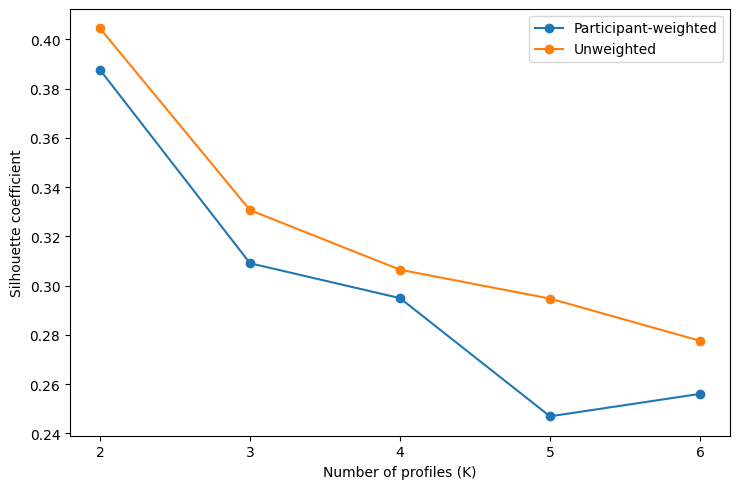

In [9]:
# ============================================================
# 8. Unweighted K-means sensitivity and K-selection figure
# ============================================================

unweighted_rows = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        n_init=30,
        random_state=RANDOM_SEED,
    )
    labels_k = model.fit_predict(X)

    unweighted_rows.append({
        "K": k,
        "Unweighted_silhouette": silhouette_score(X, labels_k),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels_k),
        "Davies_Bouldin": davies_bouldin_score(X, labels_k),
    })

unweighted_results = pd.DataFrame(unweighted_rows)
unweighted_results.to_csv(
    OUTPUT_DIR / "unweighted_kmeans_candidate_solutions.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(
    candidate_results["K"],
    candidate_results["Record_level_silhouette"],
    marker="o",
    label="Participant-weighted",
)
ax.plot(
    unweighted_results["K"],
    unweighted_results["Unweighted_silhouette"],
    marker="o",
    label="Unweighted",
)
ax.set_xlabel("Number of profiles (K)")
ax.set_ylabel("Silhouette coefficient")
ax.set_xticks(range(2, 7))
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_k_selection_silhouette.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [10]:
# ============================================================
# 9. Final two-profile solution
# ============================================================

primary_model = best_models[2]

centre_order = np.argsort(
    primary_model.cluster_centers_.mean(axis=1)
)
cluster_mapping = {
    int(centre_order[0]): 0,
    int(centre_order[1]): 1,
}

primary_labels = np.array([
    cluster_mapping[int(x)] for x in primary_model.labels_
])

analysis_df["Profile_Code"] = primary_labels
analysis_df["Profile"] = np.where(
    primary_labels == 1,
    "Higher-Intensity",
    "Lower-Intensity",
)

ordered_centres = primary_model.cluster_centers_[centre_order]

profile_centres = pd.DataFrame(
    ordered_centres,
    index=["Lower-Intensity", "Higher-Intensity"],
    columns=FEATURE_LABELS,
)
profile_centres["Overall mean"] = profile_centres.mean(axis=1)

counts = (
    analysis_df["Profile"]
    .value_counts()
    .reindex(["Lower-Intensity", "Higher-Intensity"])
)

participant_balanced_higher = (
    analysis_df.groupby("Participant_ID")["Profile_Code"].mean().mean()
)

profile_prevalence = pd.DataFrame({
    "Profile": ["Lower-Intensity", "Higher-Intensity"],
    "Record_count": [
        int(counts["Lower-Intensity"]),
        int(counts["Higher-Intensity"]),
    ],
    "Record_percent": [
        counts["Lower-Intensity"] / len(analysis_df) * 100,
        counts["Higher-Intensity"] / len(analysis_df) * 100,
    ],
    "Participant_balanced_percent": [
        (1 - participant_balanced_higher) * 100,
        participant_balanced_higher * 100,
    ],
})

profile_centres.to_csv(
    OUTPUT_DIR / "profile_centres_standardised.csv"
)
profile_prevalence.to_csv(
    OUTPUT_DIR / "profile_prevalence.csv",
    index=False,
)

print(profile_prevalence.round(3).to_string(index=False))
print("\nStandardised centres:")
print(profile_centres.round(3))

         Profile  Record_count  Record_percent  Participant_balanced_percent
 Lower-Intensity           587          37.847                        52.994
Higher-Intensity           964          62.153                        47.006

Standardised centres:
                  Gaze duration  Interaction count  Revisit count  \
Lower-Intensity          -1.092             -0.863         -1.074   
Higher-Intensity          0.527              0.119          0.470   

                  Head movement  Overall mean  
Lower-Intensity          -0.830        -0.965  
Higher-Intensity          0.293         0.352  


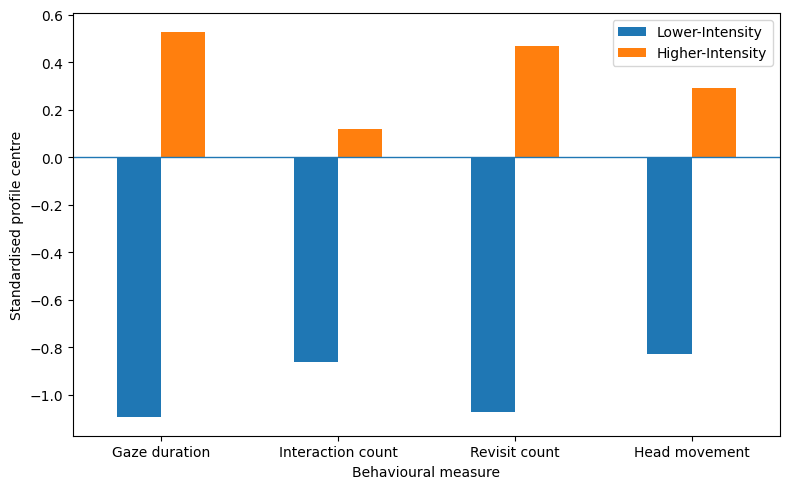

         Profile  Gaze_Duration_mean  Gaze_Duration_median  Interaction_Count_mean  Interaction_Count_median  Revisit_Count_mean  Revisit_Count_median  Head_Movement_Total_mean  Head_Movement_Total_median
 Lower-Intensity              13.243                  8.69                   2.095                       1.0               1.976                   2.0                   176.134                      148.41
Higher-Intensity             102.277                 69.17                  16.499                       8.0              13.401                  10.0                   547.215                      506.66


In [11]:
# ============================================================
# 10. Original-scale profile summaries and profile-centre figure
# ============================================================

summary_rows = []

for profile in ["Lower-Intensity", "Higher-Intensity"]:
    subset = analysis_df.loc[analysis_df["Profile"] == profile]
    row = {"Profile": profile}
    for feature in FEATURES_ORIGINAL:
        row[f"{feature}_mean"] = subset[feature].mean()
        row[f"{feature}_median"] = subset[feature].median()
    summary_rows.append(row)

profile_original_scale = pd.DataFrame(summary_rows)
profile_original_scale.to_csv(
    OUTPUT_DIR / "profile_original_scale_summary.csv",
    index=False,
)

plot_centres = profile_centres[FEATURE_LABELS].T
ax = plot_centres.plot(kind="bar", figsize=(8, 5))
ax.axhline(0, linewidth=1)
ax.set_ylabel("Standardised profile centre")
ax.set_xlabel("Behavioural measure")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_standardized_profile_centres.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(profile_original_scale.round(3).to_string(index=False))

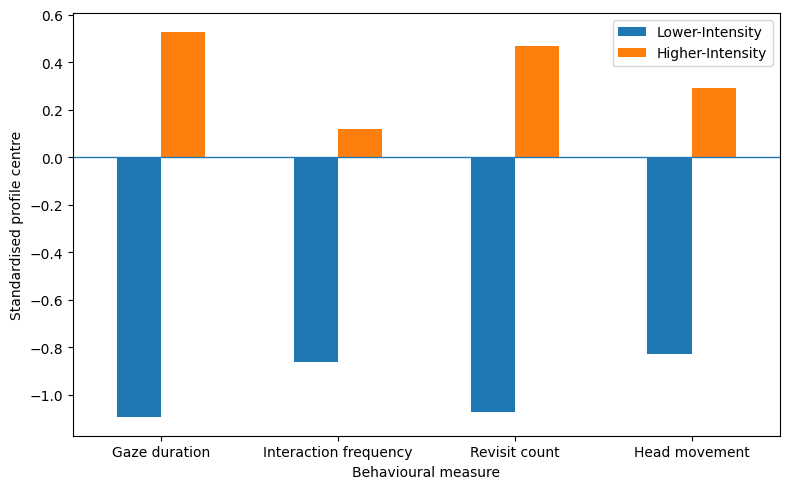

         Profile  Gaze_Duration_mean  Gaze_Duration_median  Interaction_Count_mean  Interaction_Count_median  Revisit_Count_mean  Revisit_Count_median  Head_Movement_Total_mean  Head_Movement_Total_median
 Lower-Intensity              13.243                  8.69                   2.095                       1.0               1.976                   2.0                   176.134                      148.41
Higher-Intensity             102.277                 69.17                  16.499                       8.0              13.401                  10.0                   547.215                      506.66


In [46]:
# ============================================================
# 10. Original-scale profile summaries and profile-centre figure
# ============================================================

summary_rows = []

for profile in ["Lower-Intensity", "Higher-Intensity"]:

    subset = analysis_df.loc[
        analysis_df["Profile"] == profile
    ]

    row = {"Profile": profile}

    for feature in FEATURES_ORIGINAL:
        row[f"{feature}_mean"] = subset[feature].mean()
        row[f"{feature}_median"] = subset[feature].median()

    summary_rows.append(row)


# ------------------------------------------------------------
# Original-scale profile summary
# ------------------------------------------------------------

profile_original_scale = pd.DataFrame(summary_rows)

profile_original_scale.to_csv(
    OUTPUT_DIR / "profile_original_scale_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# Standardised profile-centre figure
# ------------------------------------------------------------

plot_centres = profile_centres[FEATURE_LABELS].T.copy()

# Publication-facing labels only.
# The underlying dataframe/analysis variable names are unchanged.
display_label_map = {
    "Gaze_Duration": "Gaze duration",
    "Gaze duration": "Gaze duration",
    "Z_Gaze": "Gaze duration",

    "Interaction_Count": "Interaction frequency",
    "Interaction count": "Interaction frequency",
    "Z_Interaction": "Interaction frequency",

    "Revisit_Count": "Revisit count",
    "Revisit count": "Revisit count",
    "Z_Revisit": "Revisit count",

    "Head_Movement_Total": "Head movement",
    "Head movement": "Head movement",
    "Z_Head_Movement": "Head movement",
}

plot_centres.index = [
    display_label_map.get(label, label)
    for label in plot_centres.index
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

ax = plot_centres.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_ylabel(
    "Standardised profile centre"
)

ax.set_xlabel(
    "Behavioural measure"
)

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_standardized_profile_centres.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Display original-scale summary
# ------------------------------------------------------------

print(
    profile_original_scale
    .round(3)
    .to_string(index=False)
)

## Algorithmic robustness

The earlier 14-participant analysis used five records per participant in balanced subsamples. That procedure is not retained here because one participant in the 36-participant cohort contributes only one record. Excluding that participant solely to preserve the old subsampling design would weaken the participant-aware analysis. Instead, algorithmic sensitivity is assessed on the full analytical cohort and participant-level robustness is evaluated with leave-one-participant-out and participant bootstrap procedures.

In [12]:
# ============================================================
# 11. Alternative clustering algorithms
# ============================================================

algorithm_labels = {
    "Participant-weighted K-means": primary_labels.copy()
}

unweighted_model = KMeans(
    n_clusters=2,
    n_init=30,
    random_state=RANDOM_SEED,
)
algorithm_labels["Unweighted K-means"] = intensity_align(
    unweighted_model.fit_predict(X), X
)

gmm_model = GaussianMixture(
    n_components=2,
    covariance_type="full",
    n_init=10,
    random_state=RANDOM_SEED,
)
algorithm_labels["Gaussian mixture"] = intensity_align(
    gmm_model.fit(X).predict(X), X
)

agg_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward",
)
algorithm_labels["Agglomerative clustering"] = intensity_align(
    agg_model.fit_predict(X), X
)

algorithm_names = list(algorithm_labels)

ari_matrix = pd.DataFrame(
    np.eye(len(algorithm_names)),
    index=algorithm_names,
    columns=algorithm_names,
)
agreement_matrix = ari_matrix.copy()
pairwise_rows = []

for a, b in combinations(algorithm_names, 2):
    ari = adjusted_rand_score(algorithm_labels[a], algorithm_labels[b])
    agreement = np.mean(algorithm_labels[a] == algorithm_labels[b])

    ari_matrix.loc[a, b] = ari
    ari_matrix.loc[b, a] = ari
    agreement_matrix.loc[a, b] = agreement
    agreement_matrix.loc[b, a] = agreement

    pairwise_rows.append({
        "Method_1": a,
        "Method_2": b,
        "ARI": ari,
        "Assignment_agreement": agreement,
        "Assignment_agreement_percent": agreement * 100,
    })

algorithm_pairwise = pd.DataFrame(pairwise_rows)

ari_matrix.to_csv(OUTPUT_DIR / "algorithm_ari_matrix.csv")
agreement_matrix.to_csv(
    OUTPUT_DIR / "algorithm_assignment_agreement_matrix.csv"
)
algorithm_pairwise.to_csv(
    OUTPUT_DIR / "algorithm_pairwise_agreement.csv",
    index=False,
)

print(algorithm_pairwise.round(4).to_string(index=False))

                    Method_1                 Method_2    ARI  Assignment_agreement  Assignment_agreement_percent
Participant-weighted K-means       Unweighted K-means 0.6175                0.8930                       89.2972
Participant-weighted K-means         Gaussian mixture 0.6317                0.8975                       89.7485
Participant-weighted K-means Agglomerative clustering 0.5126                0.8607                       86.0735
          Unweighted K-means         Gaussian mixture 0.7208                0.9246                       92.4565
          Unweighted K-means Agglomerative clustering 0.2622                0.7563                       75.6286
            Gaussian mixture Agglomerative clustering 0.2712                0.7608                       76.0799


In [13]:
# ============================================================
# 12. Algorithmic consensus
# ============================================================

consensus_matrix = np.column_stack([
    algorithm_labels[name] for name in algorithm_names
])
higher_votes = consensus_matrix.sum(axis=1)

unanimous = (higher_votes == 0) | (higher_votes == 4)
three_of_four = (higher_votes == 1) | (higher_votes == 3)
two_vs_two = higher_votes == 2

consensus_summary = pd.DataFrame({
    "Consensus_level": [
        "Unanimous 4/4",
        "Majority 3/4",
        "No majority 2/2",
        "Unanimous or majority",
    ],
    "Records": [
        int(unanimous.sum()),
        int(three_of_four.sum()),
        int(two_vs_two.sum()),
        int((unanimous | three_of_four).sum()),
    ],
    "Percent": [
        unanimous.mean() * 100,
        three_of_four.mean() * 100,
        two_vs_two.mean() * 100,
        (unanimous | three_of_four).mean() * 100,
    ],
})

consensus_summary.to_csv(
    OUTPUT_DIR / "algorithm_consensus_summary.csv",
    index=False,
)

print(consensus_summary.round(3).to_string(index=False))

      Consensus_level  Records  Percent
        Unanimous 4/4     1118   72.083
         Majority 3/4      325   20.954
      No majority 2/2      108    6.963
Unanimous or majority     1443   93.037


In [14]:
# ============================================================
# 13. Leave-one-participant-out validation
# ============================================================

reference_labels = primary_labels.copy()
lopo_rows = []

for participant in sorted(analysis_df["Participant_ID"].unique()):
    train_mask = analysis_df["Participant_ID"].to_numpy() != participant
    test_mask = ~train_mask

    train_df = analysis_df.loc[train_mask]
    test_df = analysis_df.loc[test_mask]

    fold_scaler = StandardScaler()
    X_train = fold_scaler.fit_transform(train_df[FEATURES_TRANSFORMED])
    X_test = fold_scaler.transform(test_df[FEATURES_TRANSFORMED])

    train_counts = train_df.groupby("Participant_ID").size()
    train_weights = train_df["Participant_ID"].map(
        lambda p: 1.0 / train_counts[p]
    ).to_numpy()

    fold_model = KMeans(
        n_clusters=2,
        n_init=30,
        random_state=RANDOM_SEED,
    )
    fold_model.fit(X_train, sample_weight=train_weights)

    order = np.argsort(fold_model.cluster_centers_.mean(axis=1))
    mapping = {int(order[0]): 0, int(order[1]): 1}

    train_pred = np.array([
        mapping[int(x)] for x in fold_model.labels_
    ])

    raw_test_pred = np.argmin(
        cdist(X_test, fold_model.cluster_centers_),
        axis=1,
    )
    test_pred = np.array([
        mapping[int(x)] for x in raw_test_pred
    ])

    lopo_rows.append({
        "Participant_ID": participant,
        "Heldout_records": int(test_mask.sum()),
        "Training_ARI": adjusted_rand_score(
            reference_labels[train_mask],
            train_pred,
        ),
        "Heldout_assignment_agreement": np.mean(
            reference_labels[test_mask] == test_pred
        ),
    })

lopo_results = pd.DataFrame(lopo_rows)
lopo_results["Heldout_assignment_agreement_percent"] = (
    lopo_results["Heldout_assignment_agreement"] * 100
)

lopo_results.to_csv(
    OUTPUT_DIR / "lopo_validation.csv",
    index=False,
)

print(lopo_results.describe().round(4))

       Heldout_records  Training_ARI  Heldout_assignment_agreement  \
count          36.0000       36.0000                       36.0000   
mean           43.0833        0.9795                        0.9959   
std            35.9399        0.0266                        0.0112   
min             1.0000        0.9057                        0.9545   
25%            21.7500        0.9648                        1.0000   
50%            32.0000        0.9945                        1.0000   
75%            48.0000        0.9974                        1.0000   
max           166.0000        1.0000                        1.0000   

       Heldout_assignment_agreement_percent  
count                               36.0000  
mean                                99.5876  
std                                  1.1158  
min                                 95.4545  
25%                                100.0000  
50%                                100.0000  
75%                                100.0000  
m

In [15]:
# ============================================================
# 14. Participant-level bootstrap validation
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)
participant_ids = np.array(
    sorted(analysis_df["Participant_ID"].unique())
)

bootstrap_rows = []

for bootstrap_index in range(N_BOOTSTRAP):
    sampled_participants = rng.choice(
        participant_ids,
        size=len(participant_ids),
        replace=True,
    )

    parts = []
    for draw_index, participant in enumerate(sampled_participants):
        part = analysis_df.loc[
            analysis_df["Participant_ID"] == participant
        ].copy()
        part["Bootstrap_Unit"] = f"B{draw_index:03d}"
        parts.append(part)

    bootstrap_df = pd.concat(parts, ignore_index=True)

    bootstrap_scaler = StandardScaler()
    X_boot = bootstrap_scaler.fit_transform(
        bootstrap_df[FEATURES_TRANSFORMED]
    )

    unit_counts = bootstrap_df.groupby("Bootstrap_Unit").size()
    bootstrap_weights = bootstrap_df["Bootstrap_Unit"].map(
        lambda u: 1.0 / unit_counts[u]
    ).to_numpy()

    bootstrap_model = KMeans(
        n_clusters=2,
        n_init=10,
        random_state=RANDOM_SEED + bootstrap_index,
    )
    bootstrap_model.fit(
        X_boot,
        sample_weight=bootstrap_weights,
    )

    order = np.argsort(
        bootstrap_model.cluster_centers_.mean(axis=1)
    )
    mapping = {int(order[0]): 0, int(order[1]): 1}

    X_reference_scaled = bootstrap_scaler.transform(
        analysis_df[FEATURES_TRANSFORMED]
    )
    raw_prediction = np.argmin(
        cdist(
            X_reference_scaled,
            bootstrap_model.cluster_centers_,
        ),
        axis=1,
    )
    prediction = np.array([
        mapping[int(x)] for x in raw_prediction
    ])

    bootstrap_rows.append({
        "Bootstrap_iteration": bootstrap_index + 1,
        "Distinct_participants": len(set(sampled_participants)),
        "ARI": adjusted_rand_score(
            reference_labels,
            prediction,
        ),
        "Assignment_agreement": np.mean(
            reference_labels == prediction
        ),
    })

bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_results["Assignment_agreement_percent"] = (
    bootstrap_results["Assignment_agreement"] * 100
)

bootstrap_results.to_csv(
    OUTPUT_DIR / "bootstrap_stability.csv",
    index=False,
)

bootstrap_summary = pd.DataFrame({
    "Metric": [
        "Iterations",
        "Mean ARI",
        "Median ARI",
        "ARI 2.5th percentile",
        "ARI 97.5th percentile",
        "Mean assignment agreement",
        "Median assignment agreement",
        "Mean distinct participants",
        "Minimum distinct participants",
        "Maximum distinct participants",
    ],
    "Value": [
        N_BOOTSTRAP,
        bootstrap_results["ARI"].mean(),
        bootstrap_results["ARI"].median(),
        bootstrap_results["ARI"].quantile(0.025),
        bootstrap_results["ARI"].quantile(0.975),
        bootstrap_results["Assignment_agreement"].mean(),
        bootstrap_results["Assignment_agreement"].median(),
        bootstrap_results["Distinct_participants"].mean(),
        bootstrap_results["Distinct_participants"].min(),
        bootstrap_results["Distinct_participants"].max(),
    ],
})

bootstrap_summary.to_csv(
    OUTPUT_DIR / "bootstrap_stability_summary.csv",
    index=False,
)

print(bootstrap_summary.round(4).to_string(index=False))

                       Metric    Value
                   Iterations 500.0000
                     Mean ARI   0.8738
                   Median ARI   0.8834
         ARI 2.5th percentile   0.6957
        ARI 97.5th percentile   0.9871
    Mean assignment agreement   0.9671
  Median assignment agreement   0.9700
   Mean distinct participants  22.9280
Minimum distinct participants  17.0000
Maximum distinct participants  28.0000


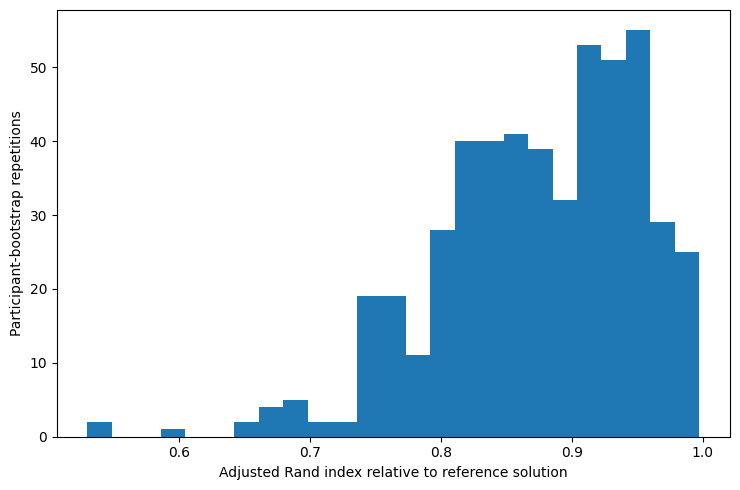

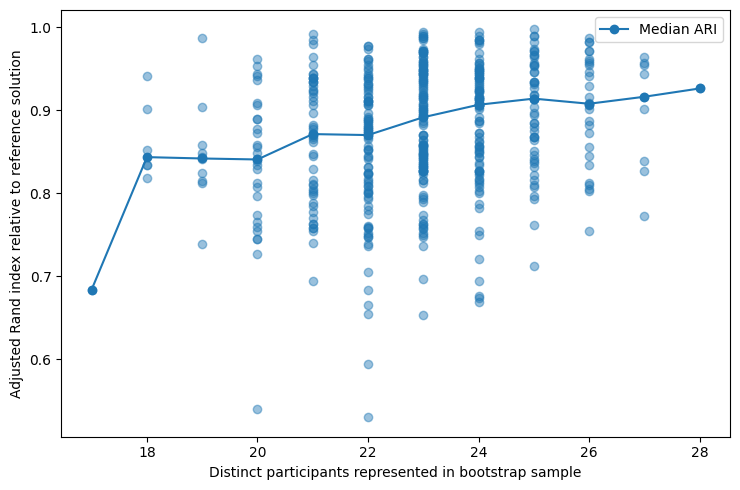

In [16]:
# ============================================================
# 15. Bootstrap figures
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(bootstrap_results["ARI"], bins=25)
ax.set_xlabel("Adjusted Rand index relative to reference solution")
ax.set_ylabel("Participant-bootstrap repetitions")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_participant_bootstrap_stability.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

median_by_distinct = (
    bootstrap_results.groupby("Distinct_participants")["ARI"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(
    bootstrap_results["Distinct_participants"],
    bootstrap_results["ARI"],
    alpha=0.45,
)
ax.plot(
    median_by_distinct["Distinct_participants"],
    median_by_distinct["ARI"],
    marker="o",
    label="Median ARI",
)
ax.set_xlabel("Distinct participants represented in bootstrap sample")
ax.set_ylabel("Adjusted Rand index relative to reference solution")
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_bootstrap_ari_by_distinct_participants.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

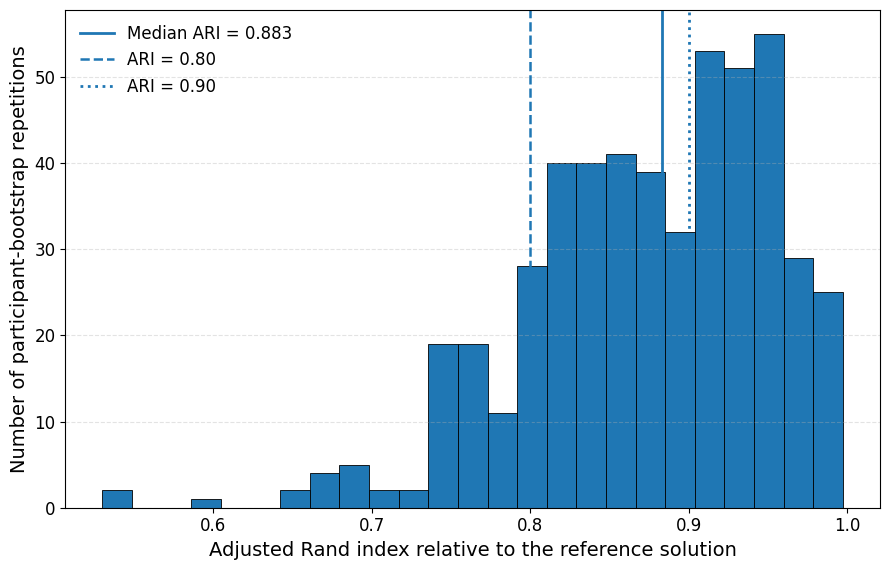

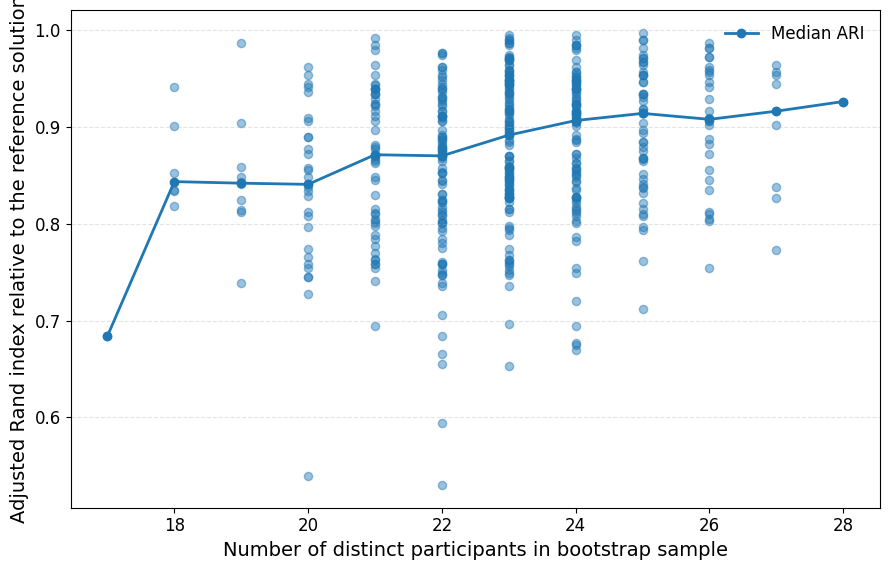

Bootstrap median ARI: 0.883
Reference lines shown at ARI = 0.80 and ARI = 0.90


In [17]:
# ============================================================
# 15. Bootstrap figures
# ============================================================

# ------------------------------------------------------------
# Figure 1: Distribution of bootstrap ARI values
# ------------------------------------------------------------

median_ari = bootstrap_results["ARI"].median()

fig, ax = plt.subplots(figsize=(9.0, 5.8))

ax.hist(
    bootstrap_results["ARI"],
    bins=25,
    edgecolor="black",
    linewidth=0.6
)

# Median ARI
ax.axvline(
    median_ari,
    linestyle="-",
    linewidth=2.0,
    label=f"Median ARI = {median_ari:.3f}"
)

# Reference ARI = 0.80
ax.axvline(
    0.80,
    linestyle="--",
    linewidth=1.8,
    label="ARI = 0.80"
)

# Reference ARI = 0.90
ax.axvline(
    0.90,
    linestyle=":",
    linewidth=2.0,
    label="ARI = 0.90"
)

# Axis labels
ax.set_xlabel(
    "Adjusted Rand index relative to the reference solution",
    fontsize=14
)

ax.set_ylabel(
    "Number of participant-bootstrap repetitions",
    fontsize=14
)

# Tick-label size
ax.tick_params(
    axis="both",
    labelsize=12
)

# Light horizontal grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# Legend
ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=12
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "figure_participant_bootstrap_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Figure 2: Bootstrap ARI by number of distinct participants
# ------------------------------------------------------------

median_by_distinct = (
    bootstrap_results
    .groupby("Distinct_participants")["ARI"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9.0, 5.8))

ax.scatter(
    bootstrap_results["Distinct_participants"],
    bootstrap_results["ARI"],
    alpha=0.45,
    s=35
)

ax.plot(
    median_by_distinct["Distinct_participants"],
    median_by_distinct["ARI"],
    marker="o",
    linewidth=2.0,
    markersize=6,
    label="Median ARI"
)

ax.set_xlabel(
    "Number of distinct participants in bootstrap sample",
    fontsize=14
)

ax.set_ylabel(
    "Adjusted Rand index relative to the reference solution",
    fontsize=14
)

ax.tick_params(
    axis="both",
    labelsize=12
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.legend(
    loc="best",
    frameon=False,
    fontsize=12
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "figure_bootstrap_ari_by_distinct_participants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Print values used in the figures
# ------------------------------------------------------------

print(
    f"Bootstrap median ARI: {median_ari:.3f}"
)

print(
    "Reference lines shown at ARI = 0.80 and ARI = 0.90"
)

In [18]:
# ============================================================
# 16. Feature ablation
# ============================================================

feature_display = dict(zip(FEATURES_TRANSFORMED, FEATURE_LABELS))
ablation_rows = []

for omitted in FEATURES_TRANSFORMED:
    retained = [f for f in FEATURES_TRANSFORMED if f != omitted]

    subset_scaler = StandardScaler()
    X_subset = subset_scaler.fit_transform(analysis_df[retained])

    model = KMeans(
        n_clusters=2,
        n_init=30,
        random_state=RANDOM_SEED,
    )
    raw_labels = model.fit_predict(
        X_subset,
        sample_weight=participant_weights,
    )
    aligned = intensity_align(raw_labels, X_subset)

    ablation_rows.append({
        "Omitted_feature": feature_display[omitted],
        "ARI_vs_full": adjusted_rand_score(
            reference_labels, aligned
        ),
        "Assignment_agreement": np.mean(
            reference_labels == aligned
        ),
        "Participant_balanced_silhouette": participant_balanced_silhouette(
            X_subset,
            aligned,
            analysis_df["Participant_ID"],
        ),
    })

feature_ablation = pd.DataFrame(ablation_rows)
feature_ablation["Assignment_agreement_percent"] = (
    feature_ablation["Assignment_agreement"] * 100
)

feature_ablation.to_csv(
    OUTPUT_DIR / "feature_ablation.csv",
    index=False,
)

print(feature_ablation.round(4).to_string(index=False))

  Omitted_feature  ARI_vs_full  Assignment_agreement  Participant_balanced_silhouette  Assignment_agreement_percent
    Gaze duration       0.6712                0.9097                           0.4517                       90.9736
Interaction count       0.8194                0.9529                           0.4216                       95.2934
    Revisit count       0.8222                0.9536                           0.3877                       95.3578
    Head movement       0.7751                0.9407                           0.4174                       94.0683


In [19]:
# ============================================================
# 17. Single-feature and PC1-only sensitivity
# ============================================================

sensitivity_rows = []

for feature in FEATURES_TRANSFORMED:
    X_single = StandardScaler().fit_transform(
        analysis_df[[feature]]
    )
    model = KMeans(
        n_clusters=2,
        n_init=30,
        random_state=RANDOM_SEED,
    )
    raw = model.fit_predict(
        X_single,
        sample_weight=participant_weights,
    )
    aligned = intensity_align(raw, X_single)

    sensitivity_rows.append({
        "Representation": feature_display[feature],
        "ARI_vs_full": adjusted_rand_score(
            reference_labels, aligned
        ),
        "Assignment_agreement": np.mean(
            reference_labels == aligned
        ),
    })

X_pc1 = analysis_df[["PC1"]].to_numpy()
pc1_model = KMeans(
    n_clusters=2,
    n_init=30,
    random_state=RANDOM_SEED,
)
pc1_raw = pc1_model.fit_predict(
    X_pc1,
    sample_weight=participant_weights,
)
pc1_labels = intensity_align(pc1_raw, X_pc1)

sensitivity_rows.append({
    "Representation": "PC1 only",
    "ARI_vs_full": adjusted_rand_score(
        reference_labels, pc1_labels
    ),
    "Assignment_agreement": np.mean(
        reference_labels == pc1_labels
    ),
})

representation_sensitivity = pd.DataFrame(sensitivity_rows)
representation_sensitivity["Assignment_agreement_percent"] = (
    representation_sensitivity["Assignment_agreement"] * 100
)

representation_sensitivity.to_csv(
    OUTPUT_DIR / "single_feature_and_pc1_sensitivity.csv",
    index=False,
)

print(representation_sensitivity.round(4).to_string(index=False))

   Representation  ARI_vs_full  Assignment_agreement  Assignment_agreement_percent
    Gaze duration       0.4676                0.8453                       84.5261
Interaction count       0.1901                0.7202                       72.0181
    Revisit count       0.5714                0.8781                       87.8143
    Head movement       0.2441                0.7479                       74.7905
         PC1 only       0.8968                0.9736                       97.3565


In [20]:
# ============================================================
# 18. Participant and object profile prevalence
# ============================================================

participant_profile = (
    analysis_df.groupby("Participant_ID")
    .agg(
        Records=("Profile_Code", "size"),
        Higher_records=("Profile_Code", "sum"),
        Higher_proportion=("Profile_Code", "mean"),
    )
    .reset_index()
)
participant_profile["Lower_records"] = (
    participant_profile["Records"]
    - participant_profile["Higher_records"]
)
participant_profile["Lower_proportion"] = (
    1 - participant_profile["Higher_proportion"]
)

object_raw = (
    analysis_df.groupby("Object_Name")
    .agg(
        Total_records=("Profile_Code", "size"),
        Higher_records=("Profile_Code", "sum"),
        Higher_record_proportion=("Profile_Code", "mean"),
    )
    .reset_index()
)

participant_object = (
    analysis_df.groupby(["Participant_ID", "Object_Name"])["Profile_Code"]
    .mean()
    .reset_index(name="Higher_proportion")
)

object_balanced = (
    participant_object.groupby("Object_Name")
    .agg(
        Participant_balanced_higher_proportion=(
            "Higher_proportion", "mean"
        ),
        Participants_represented=("Participant_ID", "nunique"),
    )
    .reset_index()
)

object_profile = object_raw.merge(
    object_balanced,
    on="Object_Name",
    how="left",
)

participant_profile.to_csv(
    OUTPUT_DIR / "participant_profile_prevalence.csv",
    index=False,
)
object_profile.to_csv(
    OUTPUT_DIR / "object_profile_prevalence.csv",
    index=False,
)

print(object_profile.round(4).to_string(index=False))

 Object_Name  Total_records  Higher_records  Higher_record_proportion  Participant_balanced_higher_proportion  Participants_represented
         Bee            195             132                    0.6769                                  0.3851                        35
    Carousel            104              42                    0.4038                                  0.2051                        34
       Chess            256             201                    0.7852                                  0.3961                        34
Eiffel Tower            123              72                    0.5854                                  0.3858                        35
     Giraffe             87              31                    0.3563                                  0.2467                        30
  Helicopter             81              34                    0.4198                                  0.2373                        34
       Laser            192             142     

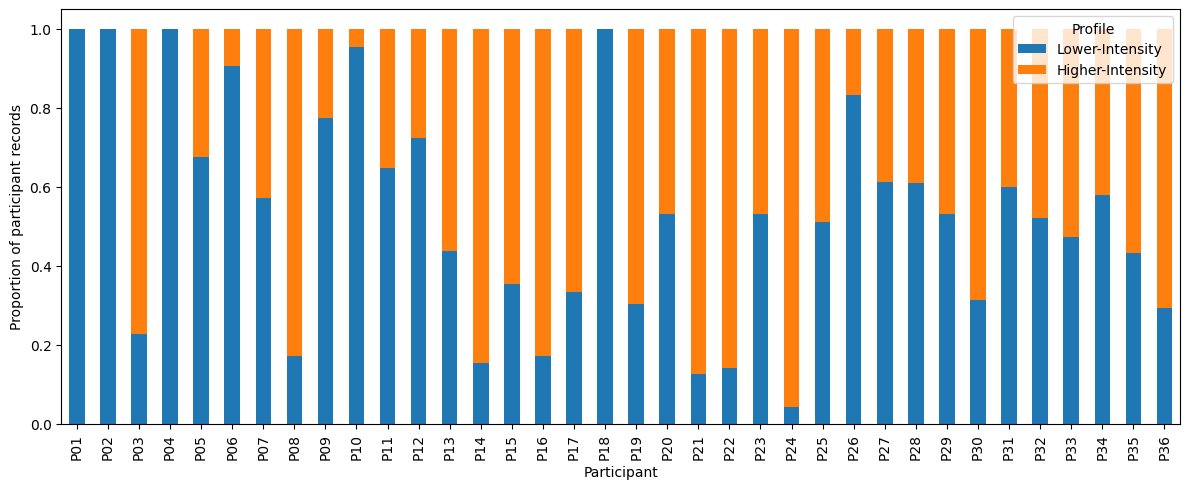

In [21]:
# ============================================================
# 19. Participant-profile composition figure
# ============================================================

participant_plot = (
    participant_profile
    .sort_values("Participant_ID")
    .set_index("Participant_ID")[
        ["Lower_proportion", "Higher_proportion"]
    ]
)

ax = participant_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
)
ax.set_ylabel("Proportion of participant records")
ax.set_xlabel("Participant")
ax.legend(
    ["Lower-Intensity", "Higher-Intensity"],
    title="Profile",
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figure_participant_profile_composition.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

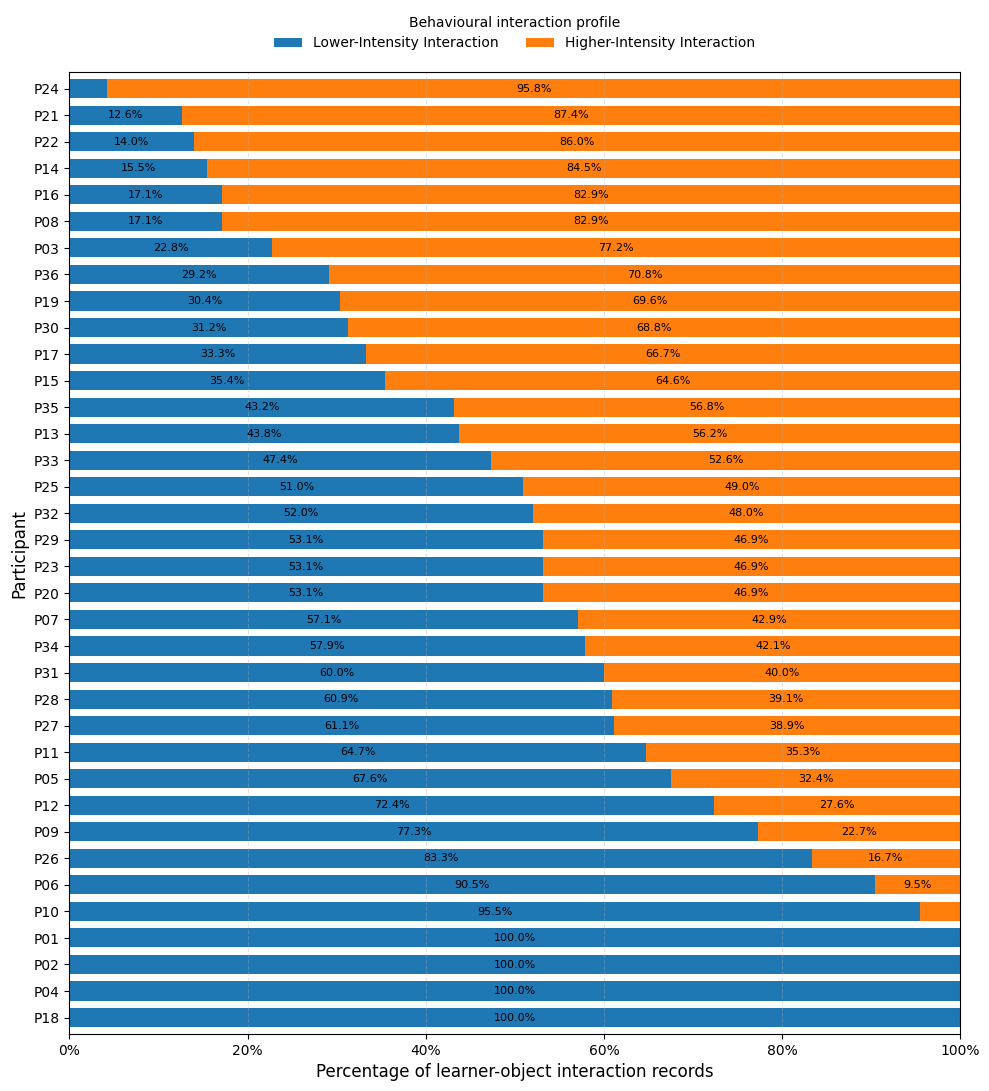

In [22]:
# ============================================================
# 19. Participant-profile composition figure
# ============================================================

from matplotlib.ticker import PercentFormatter

# Sort participants from highest Higher-Intensity prevalence
# to highest Lower-Intensity prevalence.
participant_plot = (
    participant_profile
    .sort_values("Lower_proportion", ascending=True)
    .set_index("Participant_ID")[
        ["Lower_proportion", "Higher_proportion"]
    ]
)

ax = participant_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 11),
    width=0.72,
)

# Put the participants with the greatest Higher-Intensity
# prevalence at the top of the figure.
ax.invert_yaxis()

# Axis formatting
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel(
    "Percentage of learner-object interaction records",
    fontsize=12,
)
ax.set_ylabel(
    "Participant",
    fontsize=12,
)

ax.tick_params(axis="both", labelsize=10)

# Legend above the plot
ax.legend(
    ["Lower-Intensity Interaction", "Higher-Intensity Interaction"],
    title="Behavioural interaction profile",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

# Add percentage labels inside each profile segment.
# Very small segments are left unlabelled to avoid overcrowding.
for i, (_, row) in enumerate(participant_plot.iterrows()):

    lower = row["Lower_proportion"]
    higher = row["Higher_proportion"]

    if lower >= 0.06:
        ax.text(
            lower / 2,
            i,
            f"{lower * 100:.1f}%",
            ha="center",
            va="center",
            fontsize=8,
        )

    if higher >= 0.06:
        ax.text(
            lower + higher / 2,
            i,
            f"{higher * 100:.1f}%",
            ha="center",
            va="center",
            fontsize=8,
        )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_participant_profile_composition.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [23]:
# ============================================================
# 20. Bias-corrected Cramér's V and restricted permutations
# ============================================================

def bias_corrected_cramers_v_from_codes(
    x_codes, y_codes, n_x, n_y
):
    table = np.bincount(
        x_codes * n_y + y_codes,
        minlength=n_x * n_y,
    ).reshape(n_x, n_y)

    n = table.sum()
    row_sum = table.sum(axis=1, keepdims=True)
    col_sum = table.sum(axis=0, keepdims=True)
    expected = row_sum @ col_sum / n

    valid = expected > 0
    chi2 = np.sum(
        ((table - expected) ** 2)[valid]
        / expected[valid]
    )

    phi2 = chi2 / n
    r, k = table.shape

    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1),
    )
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(
        k_corrected - 1,
        r_corrected - 1,
    )

    return np.sqrt(phi2_corrected / denominator)

def grouped_indices(values):
    s = pd.Series(np.asarray(values))
    return [
        np.asarray(idx, dtype=int)
        for idx in s.groupby(s).groups.values()
    ]

def permute_within(values, groups, rng):
    values = np.asarray(values)
    out = values.copy()
    for idx in groups:
        out[idx] = rng.permutation(values[idx])
    return out

participant_codes, participant_levels = pd.factorize(
    analysis_df["Participant_ID"],
    sort=True,
)
object_codes, object_levels = pd.factorize(
    analysis_df["Object_Name"],
    sort=True,
)
profile_codes = analysis_df["Profile_Code"].to_numpy(dtype=int)

participant_v = bias_corrected_cramers_v_from_codes(
    participant_codes,
    profile_codes,
    len(participant_levels),
    2,
)
object_v = bias_corrected_cramers_v_from_codes(
    object_codes,
    profile_codes,
    len(object_levels),
    2,
)

rng_perm = np.random.default_rng(RANDOM_SEED)

object_groups = grouped_indices(object_codes)
participant_groups = grouped_indices(participant_codes)

participant_null = np.empty(N_PERMUTATIONS)
object_null = np.empty(N_PERMUTATIONS)

for b in range(N_PERMUTATIONS):
    perm_profile = permute_within(
        profile_codes,
        object_groups,
        rng_perm,
    )
    participant_null[b] = bias_corrected_cramers_v_from_codes(
        participant_codes,
        perm_profile,
        len(participant_levels),
        2,
    )

    perm_profile = permute_within(
        profile_codes,
        participant_groups,
        rng_perm,
    )
    object_null[b] = bias_corrected_cramers_v_from_codes(
        object_codes,
        perm_profile,
        len(object_levels),
        2,
    )

participant_p = (
    1 + np.sum(participant_null >= participant_v)
) / (N_PERMUTATIONS + 1)

object_p = (
    1 + np.sum(object_null >= object_v)
) / (N_PERMUTATIONS + 1)

context_associations = pd.DataFrame({
    "Association": [
        "Participant--Profile",
        "Object--Profile",
    ],
    "Bias_corrected_Cramers_V": [
        participant_v,
        object_v,
    ],
    "Restricted_permutation_p": [
        participant_p,
        object_p,
    ],
    "Permutations": [
        N_PERMUTATIONS,
        N_PERMUTATIONS,
    ],
})

context_associations.to_csv(
    OUTPUT_DIR / "context_associations.csv",
    index=False,
)

print(context_associations.round(6).to_string(index=False))

         Association  Bias_corrected_Cramers_V  Restricted_permutation_p  Permutations
Participant--Profile                  0.527630                    0.0002          5000
     Object--Profile                  0.257417                    0.0002          5000


In [24]:
# ============================================================
# 21. Participant-adjusted object mixed model
# ============================================================

OBJECT_ORDER = [
    "Bee",
    "Carousel",
    "Chess",
    "Eiffel Tower",
    "Giraffe",
    "Helicopter",
    "Laser",
    "Mirror",
    "Pangasius",
    "Police Car",
]

mixed_df = analysis_df[
    ["Participant_ID", "Object_Name", "Profile_Code"]
].copy()
mixed_df = mixed_df.rename(
    columns={"Profile_Code": "Higher"}
)
mixed_df["Object_Name"] = pd.Categorical(
    mixed_df["Object_Name"],
    categories=OBJECT_ORDER,
)

np.random.seed(RANDOM_SEED)

object_mixed_model = BinomialBayesMixedGLM.from_formula(
    'Higher ~ C(Object_Name, Treatment(reference="Bee"))',
    {"participant": "0 + C(Participant_ID)"},
    mixed_df,
)
object_mixed_result = object_mixed_model.fit_vb()

counts_by_object = (
    mixed_df.groupby("Object_Name", observed=False)
    .agg(
        Higher_records=("Higher", "sum"),
        Total_records=("Higher", "size"),
    )
)

or_rows = [{
    "Object_Name": "Bee",
    "Higher_records": int(
        counts_by_object.loc["Bee", "Higher_records"]
    ),
    "Total_records": int(
        counts_by_object.loc["Bee", "Total_records"]
    ),
    "Odds_ratio": 1.0,
    "Lower_approx_95": np.nan,
    "Upper_approx_95": np.nan,
}]

for name, mean, sd in zip(
    object_mixed_model.exog_names,
    object_mixed_result.fe_mean,
    object_mixed_result.fe_sd,
):
    if name == "Intercept":
        continue

    object_name = name.split("[T.", 1)[1].rsplit("]", 1)[0]

    or_rows.append({
        "Object_Name": object_name,
        "Higher_records": int(
            counts_by_object.loc[object_name, "Higher_records"]
        ),
        "Total_records": int(
            counts_by_object.loc[object_name, "Total_records"]
        ),
        "Odds_ratio": np.exp(mean),
        "Lower_approx_95": np.exp(mean - 1.96 * sd),
        "Upper_approx_95": np.exp(mean + 1.96 * sd),
    })

object_odds_ratios = pd.DataFrame(or_rows)
object_odds_ratios["Object_Name"] = pd.Categorical(
    object_odds_ratios["Object_Name"],
    categories=OBJECT_ORDER,
    ordered=True,
)
object_odds_ratios = (
    object_odds_ratios
    .sort_values("Object_Name")
    .reset_index(drop=True)
)

participant_random_intercept_sd = float(
    np.exp(object_mixed_result.vcp_mean[0])
)

object_odds_ratios.to_csv(
    OUTPUT_DIR / "object_mixed_model_odds_ratios.csv",
    index=False,
)
pd.DataFrame({
    "Metric": ["Participant random-intercept SD"],
    "Value": [participant_random_intercept_sd],
}).to_csv(
    OUTPUT_DIR / "object_mixed_model_random_effect.csv",
    index=False,
)

print(object_odds_ratios.round(4).to_string(index=False))
print(
    "\nParticipant random-intercept SD:",
    round(participant_random_intercept_sd, 4),
)
print(
    "Intervals are approximate variational-posterior intervals."
)

 Object_Name  Higher_records  Total_records  Odds_ratio  Lower_approx_95  Upper_approx_95
         Bee             132            195      1.0000              NaN              NaN
    Carousel              42            104      0.2838           0.1790           0.4498
       Chess             201            256      1.1794           0.8106           1.7160
Eiffel Tower              72            123      0.9171           0.6028           1.3952
     Giraffe              31             87      0.2710           0.1633           0.4495
  Helicopter              34             81      0.4674           0.2804           0.7791
       Laser             142            192      1.9833           1.3842           2.8418
      Mirror              88            151      0.8592           0.5877           1.2563
   Pangasius             121            179      1.5895           1.1079           2.2804
  Police Car             101            183      0.6332           0.4567           0.8778

Participa

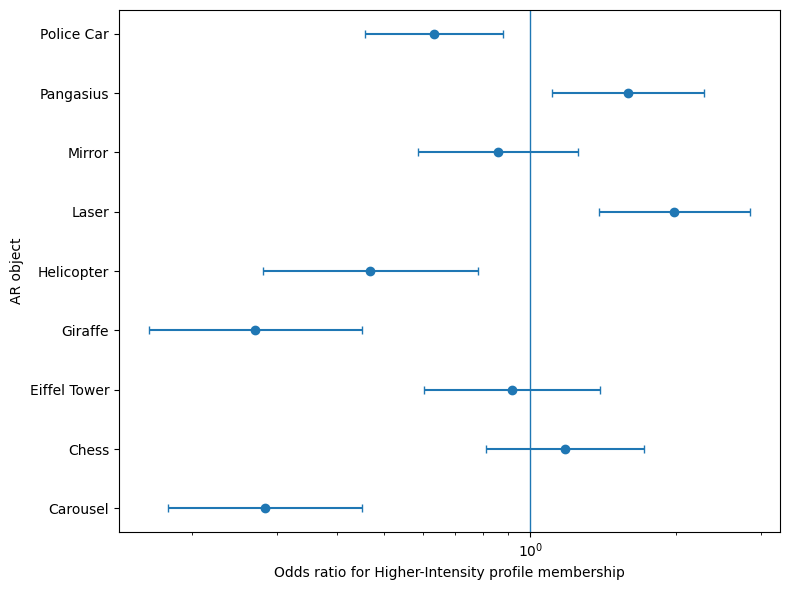

In [25]:
# ============================================================
# 22. Object odds-ratio figure
# ============================================================

plot_or = object_odds_ratios.loc[
    object_odds_ratios["Object_Name"] != "Bee"
].copy()

y_pos = np.arange(len(plot_or))
x = plot_or["Odds_ratio"].to_numpy()
lower = plot_or["Lower_approx_95"].to_numpy()
upper = plot_or["Upper_approx_95"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    x,
    y_pos,
    xerr=np.vstack([x - lower, upper - x]),
    fmt="o",
    capsize=3,
)
ax.axvline(1, linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_or["Object_Name"].astype(str))
ax.set_xlabel(
    "Odds ratio for Higher-Intensity profile membership"
)
ax.set_ylabel("AR object")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_object_effect_odds_ratios.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

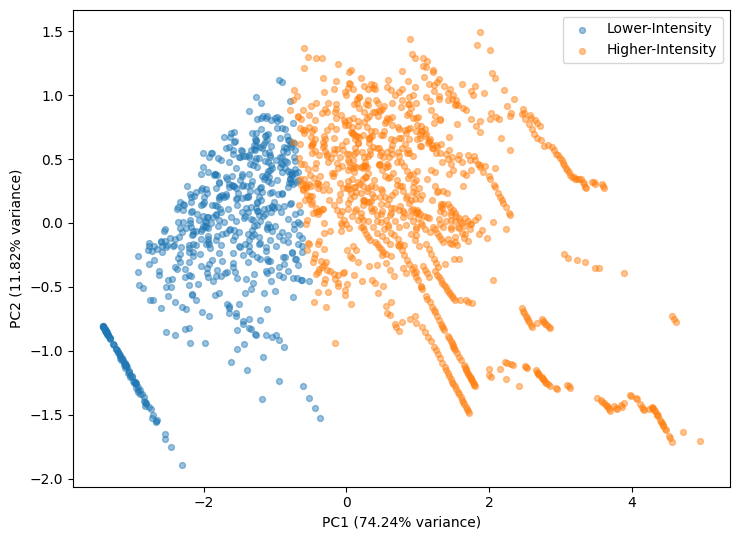

In [26]:
# ============================================================
# 23. PCA-space figure
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for profile in ["Lower-Intensity", "Higher-Intensity"]:
    subset = analysis_df.loc[
        analysis_df["Profile"] == profile
    ]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.45,
        s=18,
        label=profile,
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_profiles_in_pca_space.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

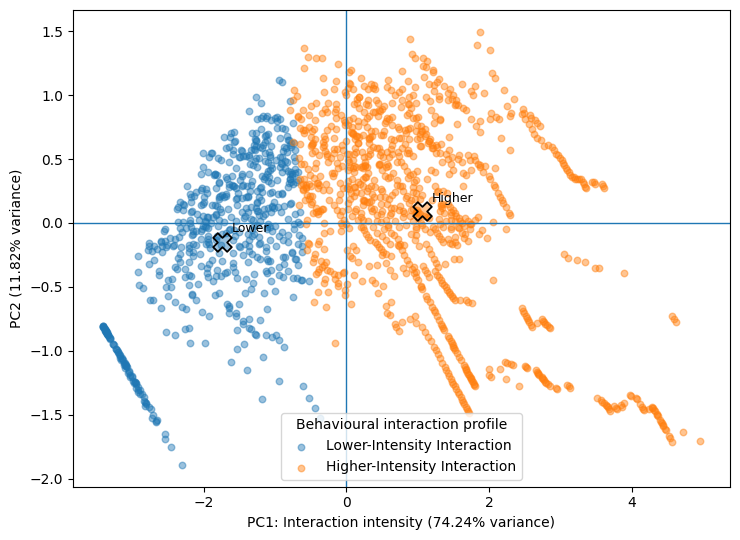


Profile centroids in PCA space:
                     PC1     PC2
Profile                         
Lower-Intensity  -1.7484 -0.1494
Higher-Intensity  1.0647  0.0910


In [27]:
# ============================================================
# 23. PCA-space figure
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# ------------------------------------------------------------
# Plot learner-object records for each interaction profile
# ------------------------------------------------------------

for profile in ["Lower-Intensity", "Higher-Intensity"]:

    subset = analysis_df.loc[
        analysis_df["Profile"] == profile
    ]

    scatter = ax.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.45,
        s=22,
        label=f"{profile} Interaction",
    )

    # --------------------------------------------------------
    # Calculate and plot the profile centroid in PCA space
    # --------------------------------------------------------

    centroid_pc1 = subset["PC1"].mean()
    centroid_pc2 = subset["PC2"].mean()

    centroid_color = scatter.get_facecolor()[0]

    ax.scatter(
        centroid_pc1,
        centroid_pc2,
        marker="X",
        s=180,
        color=centroid_color,
        edgecolor="black",
        linewidth=1.3,
        zorder=5,
    )

    # Short label beside centroid
    centroid_label = (
        "Lower"
        if profile == "Lower-Intensity"
        else "Higher"
    )

    ax.annotate(
        centroid_label,
        (centroid_pc1, centroid_pc2),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
    )


# ------------------------------------------------------------
# Reference lines at zero
# ------------------------------------------------------------

ax.axvline(
    0,
    linewidth=1,
)

ax.axhline(
    0,
    linewidth=1,
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    f"PC1: Interaction intensity "
    f"({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

ax.set_ylabel(
    f"PC2 "
    f"({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    title="Behavioural interaction profile",
    loc="best",
    frameon=True,
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "figure_profiles_in_pca_space.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Print PCA-space profile centroids for reproducibility
# ------------------------------------------------------------

pca_profile_centroids = (
    analysis_df
    .groupby("Profile")[["PC1", "PC2"]]
    .mean()
    .reindex(
        [
            "Lower-Intensity",
            "Higher-Intensity"
        ]
    )
)

print("\nProfile centroids in PCA space:")
print(
    pca_profile_centroids
    .round(4)
    .to_string()
)

pca_profile_centroids.to_csv(
    OUTPUT_DIR / "pca_profile_centroids.csv"
)

In [28]:
# ============================================================
# 24. Continuous PC1 interaction-intensity variance partition
# ============================================================

participant_model = smf.ols(
    "PC1 ~ C(Participant_ID)",
    data=analysis_df,
).fit()

object_model_ols = smf.ols(
    "PC1 ~ C(Object_Name)",
    data=analysis_df,
).fit()

combined_model = smf.ols(
    "PC1 ~ C(Participant_ID) + C(Object_Name)",
    data=analysis_df,
).fit()

r2_participant = participant_model.rsquared
r2_object = object_model_ols.rsquared
r2_combined = combined_model.rsquared

unique_participant = r2_combined - r2_object
unique_object = r2_combined - r2_participant
shared_variance = (
    r2_participant + r2_object - r2_combined
)
unexplained = 1 - r2_combined

variance_partition = pd.DataFrame({
    "Component": [
        "Participant only R2",
        "Object only R2",
        "Participant + Object R2",
        "Unique participant",
        "Unique object",
        "Shared explained variance",
        "Unexplained",
    ],
    "Proportion": [
        r2_participant,
        r2_object,
        r2_combined,
        unique_participant,
        unique_object,
        shared_variance,
        unexplained,
    ],
})

variance_partition.to_csv(
    OUTPUT_DIR / "continuous_intensity_variance_partition.csv",
    index=False,
)

print(variance_partition.round(4).to_string(index=False))

                Component  Proportion
      Participant only R2      0.4575
           Object only R2      0.1672
  Participant + Object R2      0.5052
       Unique participant      0.3380
            Unique object      0.0477
Shared explained variance      0.1195
              Unexplained      0.4948


In [29]:
# ============================================================
# 25. Restricted permutation tests for unique PC1 variance
# ============================================================

def residualise(y, design):
    beta = np.linalg.lstsq(design, y, rcond=None)[0]
    return y - design @ beta

def orthonormal_basis(extra_design, reduced_design):
    residualised = extra_design - reduced_design @ np.linalg.lstsq(
        reduced_design,
        extra_design,
        rcond=None,
    )[0]

    u, s, _ = np.linalg.svd(
        residualised,
        full_matrices=False,
    )

    tolerance = (
        np.max(residualised.shape)
        * np.finfo(float).eps
        * s.max()
    )
    rank = int(np.sum(s > tolerance))
    return u[:, :rank]

y = analysis_df["PC1"].to_numpy()
intercept = np.ones((len(analysis_df), 1))

participant_dummies = pd.get_dummies(
    analysis_df["Participant_ID"],
    drop_first=True,
    dtype=float,
).to_numpy()

object_dummies = pd.get_dummies(
    analysis_df["Object_Name"],
    drop_first=True,
    dtype=float,
).to_numpy()

X_participant = np.column_stack([
    intercept,
    participant_dummies,
])
X_object = np.column_stack([
    intercept,
    object_dummies,
])

sst = np.sum((y - y.mean()) ** 2)

y_resid_object = residualise(y, X_object)
Q_participant = orthonormal_basis(
    participant_dummies,
    X_object,
)

observed_unique_participant = (
    np.sum((Q_participant.T @ y_resid_object) ** 2)
    / sst
)

y_resid_participant = residualise(y, X_participant)
Q_object = orthonormal_basis(
    object_dummies,
    X_participant,
)

observed_unique_object = (
    np.sum((Q_object.T @ y_resid_participant) ** 2)
    / sst
)

assert np.isclose(
    observed_unique_participant,
    unique_participant,
)
assert np.isclose(
    observed_unique_object,
    unique_object,
)

rng_variance = np.random.default_rng(
    RANDOM_SEED + 1000
)

object_groups_pc1 = grouped_indices(object_codes)
participant_groups_pc1 = grouped_indices(participant_codes)

participant_null_r2 = np.empty(N_PERMUTATIONS)
object_null_r2 = np.empty(N_PERMUTATIONS)

for b in range(N_PERMUTATIONS):
    perm_y = permute_within(
        y_resid_object,
        object_groups_pc1,
        rng_variance,
    )
    participant_null_r2[b] = (
        np.sum((Q_participant.T @ perm_y) ** 2)
        / sst
    )

    perm_y = permute_within(
        y_resid_participant,
        participant_groups_pc1,
        rng_variance,
    )
    object_null_r2[b] = (
        np.sum((Q_object.T @ perm_y) ** 2)
        / sst
    )

participant_unique_p = (
    1 + np.sum(
        participant_null_r2 >= observed_unique_participant
    )
) / (N_PERMUTATIONS + 1)

object_unique_p = (
    1 + np.sum(
        object_null_r2 >= observed_unique_object
    )
) / (N_PERMUTATIONS + 1)

variance_permutation_results = pd.DataFrame({
    "Effect": [
        "Unique participant",
        "Unique object",
    ],
    "Observed_incremental_R2": [
        observed_unique_participant,
        observed_unique_object,
    ],
    "Restricted_permutation_p": [
        participant_unique_p,
        object_unique_p,
    ],
    "Permutations": [
        N_PERMUTATIONS,
        N_PERMUTATIONS,
    ],
})

variance_permutation_results.to_csv(
    OUTPUT_DIR / "continuous_intensity_permutation_tests.csv",
    index=False,
)

print(
    variance_permutation_results
    .round(6)
    .to_string(index=False)
)

            Effect  Observed_incremental_R2  Restricted_permutation_p  Permutations
Unique participant                 0.338028                    0.0002          5000
     Unique object                 0.047748                    0.0002          5000


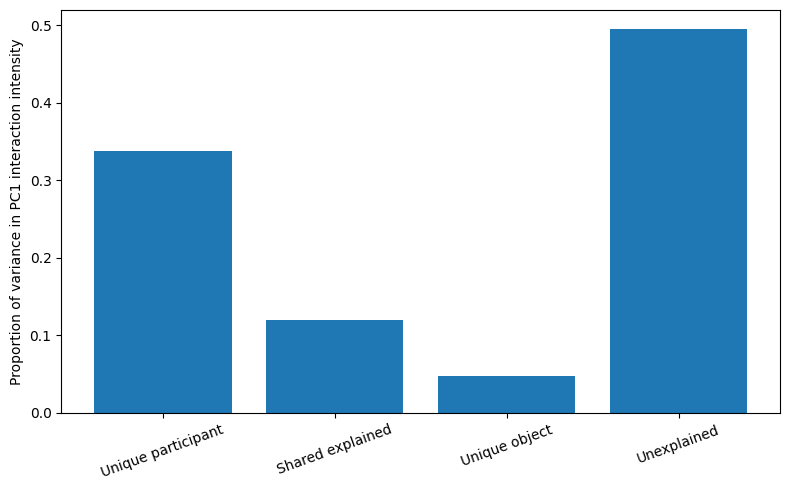

In [30]:
# ============================================================
# 26. Variance-partition figure
# ============================================================

plot_partition = pd.DataFrame({
    "Component": [
        "Unique participant",
        "Shared explained",
        "Unique object",
        "Unexplained",
    ],
    "Proportion": [
        unique_participant,
        shared_variance,
        unique_object,
        unexplained,
    ],
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    plot_partition["Component"],
    plot_partition["Proportion"],
)
ax.set_ylabel(
    "Proportion of variance in PC1 interaction intensity"
)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_continuous_intensity_variance_partition.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

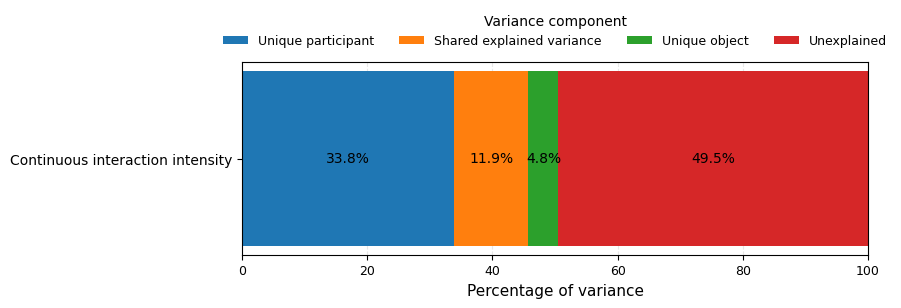

In [31]:
# ============================================================
# 26. Variance-partition figure
# ============================================================

plot_partition = pd.DataFrame({
    "Component": [
        "Unique participant",
        "Shared explained variance",
        "Unique object",
        "Unexplained",
    ],
    "Proportion": [
        unique_participant,
        shared_variance,
        unique_object,
        unexplained,
    ],
})

# Convert proportions to percentages.
# This remains safe if the values are already expressed as percentages.
values = plot_partition["Proportion"].to_numpy(dtype=float)

if values.max() <= 1:
    values_pct = values * 100
else:
    values_pct = values

components = plot_partition["Component"].tolist()

# ------------------------------------------------------------
# Horizontal 100% stacked bar
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 3.2))

left = 0

for component, value in zip(components, values_pct):

    bar = ax.barh(
        ["Continuous interaction intensity"],
        [value],
        left=left,
        label=component,
        height=0.52,
    )

    # Percentage label centred within each segment
    if value >= 4:
        ax.text(
            left + value / 2,
            0,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
        )

    left += value

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xlim(0, 100)

ax.set_xlabel(
    "Percentage of variance",
    fontsize=11,
)

ax.set_ylabel("")

ax.tick_params(
    axis="x",
    labelsize=9,
)

ax.tick_params(
    axis="y",
    labelsize=10,
)

# ------------------------------------------------------------
# Legend above the figure
# ------------------------------------------------------------

ax.legend(
    title="Variance component",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

# Light vertical reference grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

ax.set_axisbelow(True)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "figure_continuous_intensity_variance_partition.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [32]:
# ============================================================
# 27. Save final record-level analytical output
# ============================================================

analysis_df.to_csv(
    OUTPUT_DIR / "final_profile_assignments_36_participants.csv",
    index=False,
)

print(
    "Saved final profile assignments:",
    OUTPUT_DIR / "final_profile_assignments_36_participants.csv"
)

Saved final profile assignments: analysis_outputs\final_profile_assignments_36_participants.csv


In [33]:
# ============================================================
# 28. Master results summary
# ============================================================

k2 = candidate_results.loc[
    candidate_results["K"] == 2
].iloc[0]

pc1_row = representation_sensitivity.loc[
    representation_sensitivity["Representation"] == "PC1 only"
].iloc[0]

master_summary = pd.DataFrame({
    "Metric": [
        "Analytical records",
        "Participants",
        "Objects",
        "Preferred K",
        "K2 record-level silhouette",
        "K2 participant-balanced silhouette",
        "K2 Calinski-Harabasz",
        "K2 Davies-Bouldin",
        "K2 minimum seed ARI",
        "Lower-Intensity records",
        "Higher-Intensity records",
        "Participant-balanced Higher prevalence",
        "PC1 variance explained",
        "PC1-only ARI vs full profiles",
        "PC1-only assignment agreement",
        "LOPO mean training ARI",
        "LOPO mean held-out agreement",
        "Bootstrap mean ARI",
        "Bootstrap median ARI",
        "Bootstrap ARI 2.5th percentile",
        "Bootstrap median assignment agreement",
        "Participant-profile Cramers V",
        "Participant-profile permutation p",
        "Object-profile Cramers V",
        "Object-profile permutation p",
        "Participant-only R2",
        "Object-only R2",
        "Participant + Object R2",
        "Unique participant R2",
        "Unique object R2",
        "Shared explained variance",
        "Unexplained variance",
    ],
    "Value": [
        len(analysis_df),
        analysis_df["Participant_ID"].nunique(),
        analysis_df["Object_Name"].nunique(),
        2,
        k2["Record_level_silhouette"],
        k2["Participant_balanced_silhouette"],
        k2["Calinski_Harabasz"],
        k2["Davies_Bouldin"],
        k2["Minimum_seed_ARI"],
        int(counts["Lower-Intensity"]),
        int(counts["Higher-Intensity"]),
        participant_balanced_higher,
        pca.explained_variance_ratio_[0],
        pc1_row["ARI_vs_full"],
        pc1_row["Assignment_agreement"],
        lopo_results["Training_ARI"].mean(),
        lopo_results["Heldout_assignment_agreement"].mean(),
        bootstrap_results["ARI"].mean(),
        bootstrap_results["ARI"].median(),
        bootstrap_results["ARI"].quantile(0.025),
        bootstrap_results["Assignment_agreement"].median(),
        participant_v,
        participant_p,
        object_v,
        object_p,
        r2_participant,
        r2_object,
        r2_combined,
        unique_participant,
        unique_object,
        shared_variance,
        unexplained,
    ],
})

master_summary.to_csv(
    OUTPUT_DIR / "master_results_summary.csv",
    index=False,
)

print(master_summary.round(6).to_string(index=False))

                                Metric       Value
                    Analytical records 1551.000000
                          Participants   36.000000
                               Objects   10.000000
                           Preferred K    2.000000
            K2 record-level silhouette    0.387622
    K2 participant-balanced silhouette    0.398894
                  K2 Calinski-Harabasz 1367.166561
                     K2 Davies-Bouldin    0.901816
                   K2 minimum seed ARI    0.992247
               Lower-Intensity records  587.000000
              Higher-Intensity records  964.000000
Participant-balanced Higher prevalence    0.470064
                PC1 variance explained    0.742378
         PC1-only ARI vs full profiles    0.896751
         PC1-only assignment agreement    0.973565
                LOPO mean training ARI    0.979548
          LOPO mean held-out agreement    0.995876
                    Bootstrap mean ARI    0.873776
                  Bootstrap med

In [34]:
# ============================================================
# 29. Software versions
# ============================================================

software_versions = pd.DataFrame({
    "Software": [
        "Python",
        "NumPy",
        "pandas",
        "SciPy",
        "scikit-learn",
        "statsmodels",
        "matplotlib",
    ],
    "Version": [
        platform.python_version(),
        np.__version__,
        pd.__version__,
        scipy.__version__,
        sklearn.__version__,
        statsmodels.__version__,
        plt.matplotlib.__version__,
    ],
})

software_versions.to_csv(
    OUTPUT_DIR / "software_versions.csv",
    index=False,
)

print(software_versions.to_string(index=False))
print("\nAnalysis complete.")
print("All outputs are in:", OUTPUT_DIR.resolve())

    Software Version
      Python  3.9.16
       NumPy  1.26.4
      pandas   2.2.3
       SciPy  1.13.1
scikit-learn   1.6.1
 statsmodels  0.14.4
  matplotlib   3.9.4

Analysis complete.
All outputs are in: C:\Users\Onyeka\analysis_outputs


In [35]:
from sklearn.metrics import adjusted_rand_score
import numpy as np

# ------------------------------------------------------------
# PC1 median-split sensitivity analysis
# ------------------------------------------------------------

pc1_median = analysis_df["PC1"].median()

analysis_df["PC1_Median_Profile"] = np.where(
    analysis_df["PC1"] > pc1_median,
    "Higher-Intensity",
    "Lower-Intensity"
)

median_split_ari = adjusted_rand_score(
    analysis_df["Profile"],
    analysis_df["PC1_Median_Profile"]
)

median_split_agreement = (
    analysis_df["Profile"]
    .eq(analysis_df["PC1_Median_Profile"])
    .mean()
    * 100
)

print(f"PC1 median: {pc1_median:.4f}")
print(f"Median-split ARI: {median_split_ari:.3f}")
print(
    f"Median-split assignment agreement: "
    f"{median_split_agreement:.2f}%"
)

PC1 median: 0.0275
Median-split ARI: 0.572
Median-split assignment agreement: 87.81%


In [37]:
# ============================================================
# Sparse-participant sensitivity: participant-count diagnostic
# ============================================================

participant_counts = (
    analysis_df
    .groupby("Participant_ID")
    .size()
    .sort_values()
)

print("Records per participant")
print("=======================")
print(participant_counts)

print("\nSummary")
print("=======")
print(f"Number of participants: {participant_counts.size}")
print(f"Minimum records: {participant_counts.min()}")
print(f"Maximum records: {participant_counts.max()}")
print(f"Median records: {participant_counts.median():.1f}")

for threshold in [2, 5, 10]:

    excluded = participant_counts[
        participant_counts < threshold
    ]

    retained = participant_counts[
        participant_counts >= threshold
    ]

    print("\n" + "=" * 50)
    print(f"Minimum-record threshold: >= {threshold}")
    print("=" * 50)

    print(f"Participants retained: {len(retained)}")
    print(f"Participants excluded: {len(excluded)}")
    print(f"Records retained: {retained.sum()}")
    print(f"Records excluded: {excluded.sum()}")

    if len(excluded) > 0:
        print("\nExcluded participants:")
        print(excluded)
    else:
        print("\nNo participants excluded.")

Records per participant
Participant_ID
P18      1
P01      5
P30     16
P11     17
P02     18
P33     19
P34     19
P17     21
P07     21
P09     22
P10     22
P28     23
P26     24
P32     25
P04     26
P12     29
P31     30
P13     32
P29     32
P20     32
P23     32
P16     35
P27     36
P05     37
P06     42
P35     44
P36     48
P15     48
P19     56
P08     70
P03     79
P21     87
P14     97
P25    104
P22    136
P24    166
dtype: int64

Summary
Number of participants: 36
Minimum records: 1
Maximum records: 166
Median records: 32.0

Minimum-record threshold: >= 2
Participants retained: 35
Participants excluded: 1
Records retained: 1550
Records excluded: 1

Excluded participants:
Participant_ID
P18    1
dtype: int64

Minimum-record threshold: >= 5
Participants retained: 35
Participants excluded: 1
Records retained: 1550
Records excluded: 1

Excluded participants:
Participant_ID
P18    1
dtype: int64

Minimum-record threshold: >= 10
Participants retained: 34
Participants excluded:

In [43]:
# ============================================================
# Sparse-participant sensitivity analysis
# ============================================================

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_samples,
)

# ------------------------------------------------------------
# Column names
# ------------------------------------------------------------

PARTICIPANT_COL = "Participant_ID"

GAZE_COL = "Gaze_Duration"

# Keep the actual INTERNAL dataframe name here.
# If your dataframe still uses Interaction_Count, use that.
INTERACTION_COL = "Interaction_Count"

REVISIT_COL = "Revisit_Count"

HEAD_COL = "Head_Movement_Total"

RAW_FEATURES = [
    GAZE_COL,
    INTERACTION_COL,
    REVISIT_COL,
    HEAD_COL,
]

In [44]:
# ============================================================
# SPARSE-PARTICIPANT SENSITIVITY ANALYSIS
# Complete self-contained version
# ============================================================

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_samples


# ------------------------------------------------------------
# 1. Show available dataframe columns
# ------------------------------------------------------------

print("Available columns in analysis_df:")
print(analysis_df.columns.tolist())
print()


# ------------------------------------------------------------
# 2. Automatically identify relevant columns
# ------------------------------------------------------------

def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        "Could not find any of these columns:\n"
        + "\n".join(candidates)
    )


PARTICIPANT_COL = find_column(
    analysis_df,
    [
        "Participant_ID",
        "Participant",
        "participant_id",
        "participant",
    ],
)

GAZE_COL = find_column(
    analysis_df,
    [
        "Gaze_Duration",
        "Gaze Duration",
        "gaze_duration",
        "Gaze",
    ],
)

INTERACTION_COL = find_column(
    analysis_df,
    [
        "Interaction_Frequency",
        "Interaction_Count",
        "Interaction Frequency",
        "Interaction Count",
        "interaction_frequency",
        "interaction_count",
    ],
)

REVISIT_COL = find_column(
    analysis_df,
    [
        "Revisit_Count",
        "Revisit Count",
        "revisit_count",
        "Revisit",
    ],
)

HEAD_COL = find_column(
    analysis_df,
    [
        "Head_Movement_Total",
        "Head_Movement",
        "Head Movement",
        "head_movement_total",
        "head_movement",
    ],
)

PROFILE_COL = find_column(
    analysis_df,
    [
        "Profile",
        "profile",
    ],
)


print("Columns selected for analysis:")
print(f"Participant       : {PARTICIPANT_COL}")
print(f"Gaze duration     : {GAZE_COL}")
print(f"Interaction freq. : {INTERACTION_COL}")
print(f"Revisit count     : {REVISIT_COL}")
print(f"Head movement     : {HEAD_COL}")
print(f"Reference profile : {PROFILE_COL}")
print()


# ------------------------------------------------------------
# 3. Preprocessing function
# ------------------------------------------------------------

def preprocess_subset(df):

    X_raw = pd.DataFrame(
        index=df.index
    )

    # Same preprocessing as primary analysis
    X_raw["Gaze"] = np.log1p(
        pd.to_numeric(df[GAZE_COL], errors="raise")
    )

    X_raw["Interaction"] = np.log1p(
        pd.to_numeric(df[INTERACTION_COL], errors="raise")
    )

    X_raw["Revisit"] = np.log1p(
        pd.to_numeric(df[REVISIT_COL], errors="raise")
    )

    X_raw["Head"] = pd.to_numeric(
        df[HEAD_COL],
        errors="raise",
    )

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X_raw[
            ["Gaze", "Interaction", "Revisit", "Head"]
        ]
    )

    return X_scaled


# ------------------------------------------------------------
# 4. Participant weights
# ------------------------------------------------------------

def calculate_participant_weights(df):

    n_per_participant = (
        df
        .groupby(PARTICIPANT_COL)[PARTICIPANT_COL]
        .transform("size")
    )

    return (
        1.0 / n_per_participant
    ).to_numpy()


# ------------------------------------------------------------
# 5. Weighted K-means fitting
# ------------------------------------------------------------

def fit_participant_weighted_kmeans(X, weights):

    best_model = None
    best_inertia = np.inf

    for seed in range(30):

        model = KMeans(
            n_clusters=2,
            random_state=seed,
            n_init=10,
        )

        model.fit(
            X,
            sample_weight=weights,
        )

        if model.inertia_ < best_inertia:
            best_inertia = model.inertia_
            best_model = model

    return best_model


# ------------------------------------------------------------
# 6. Convert arbitrary cluster numbers into intensity labels
# ------------------------------------------------------------

def convert_to_intensity_labels(model):

    centre_intensity = (
        model.cluster_centers_
        .mean(axis=1)
    )

    lower_cluster = np.argmin(
        centre_intensity
    )

    higher_cluster = np.argmax(
        centre_intensity
    )

    mapping = {
        lower_cluster: "Lower-Intensity",
        higher_cluster: "Higher-Intensity",
    }

    labels = np.array(
        [
            mapping[x]
            for x in model.labels_
        ]
    )

    return labels


# ------------------------------------------------------------
# 7. Participant-balanced silhouette
# ------------------------------------------------------------

def balanced_silhouette(
    X,
    numeric_labels,
    participant_ids,
):

    record_sil = silhouette_samples(
        X,
        numeric_labels,
    )

    temp = pd.DataFrame({
        "Participant": participant_ids,
        "Silhouette": record_sil,
    })

    participant_means = (
        temp
        .groupby("Participant")["Silhouette"]
        .mean()
    )

    return participant_means.mean()


# ------------------------------------------------------------
# 8. Participant counts
# ------------------------------------------------------------

participant_counts = (
    analysis_df
    .groupby(PARTICIPANT_COL)
    .size()
)

print("Participant contribution summary:")
print(
    participant_counts
    .sort_values()
    .to_string()
)

print()


# ------------------------------------------------------------
# 9. Sensitivity specifications
# ------------------------------------------------------------

sensitivity_conditions = [
    {
        "Specification":
            "Exclude one-record participant",
        "Minimum_records": 2,
    },
    {
        "Specification":
            "Exclude participants with <=5 records",
        "Minimum_records": 6,
    },
]


# ------------------------------------------------------------
# 10. Run sensitivity analyses
# ------------------------------------------------------------

results = []

for condition in sensitivity_conditions:

    specification = condition["Specification"]
    minimum_records = condition["Minimum_records"]

    print("=" * 70)
    print(specification)
    print("=" * 70)

    eligible = (
        participant_counts[
            participant_counts >= minimum_records
        ]
        .index
    )

    excluded = (
        participant_counts[
            participant_counts < minimum_records
        ]
    )

    subset = (
        analysis_df[
            analysis_df[PARTICIPANT_COL]
            .isin(eligible)
        ]
        .copy()
    )

    print(
        f"Participants retained: "
        f"{subset[PARTICIPANT_COL].nunique()}"
    )

    print(
        f"Records retained: "
        f"{len(subset)}"
    )

    print("Excluded participants:")

    if len(excluded) == 0:
        print("None")
    else:
        print(
            excluded
            .sort_values()
            .to_string()
        )

    # Re-estimate preprocessing
    X = preprocess_subset(
        subset
    )

    # Recalculate participant weights
    weights = calculate_participant_weights(
        subset
    )

    # Refit participant-weighted K-means
    model = fit_participant_weighted_kmeans(
        X,
        weights,
    )

    new_profiles = convert_to_intensity_labels(
        model
    )

    # Original reference labels for exactly these records
    reference_profiles = (
        subset[PROFILE_COL]
        .astype(str)
        .to_numpy()
    )

    # ARI
    ari = adjusted_rand_score(
        reference_profiles,
        new_profiles,
    )

    # Exact assignment agreement
    agreement = (
        reference_profiles
        == new_profiles
    ).mean() * 100

    # Participant-balanced silhouette
    bal_sil = balanced_silhouette(
        X,
        model.labels_,
        subset[PARTICIPANT_COL].to_numpy(),
    )

    lower_n = np.sum(
        new_profiles == "Lower-Intensity"
    )

    higher_n = np.sum(
        new_profiles == "Higher-Intensity"
    )

    print()
    print(f"ARI: {ari:.4f}")
    print(
        f"Assignment agreement: "
        f"{agreement:.2f}%"
    )
    print(
        f"Participant-balanced silhouette: "
        f"{bal_sil:.4f}"
    )
    print(
        f"Lower-Intensity records: "
        f"{lower_n}"
    )
    print(
        f"Higher-Intensity records: "
        f"{higher_n}"
    )

    print()

    results.append({
        "Specification":
            specification,

        "Participants":
            subset[
                PARTICIPANT_COL
            ].nunique(),

        "Records":
            len(subset),

        "ARI":
            ari,

        "Agreement_percent":
            agreement,

        "Participant_balanced_silhouette":
            bal_sil,

        "Lower_records":
            lower_n,

        "Higher_records":
            higher_n,
    })


# ------------------------------------------------------------
# 11. Final table
# ------------------------------------------------------------

sparse_sensitivity = pd.DataFrame(
    results
)

print("\nFINAL SPARSE-PARTICIPANT SENSITIVITY TABLE")
print("=" * 70)

print(
    sparse_sensitivity
    .round({
        "ARI": 4,
        "Agreement_percent": 2,
        "Participant_balanced_silhouette": 4,
    })
    .to_string(index=False)
)


# ------------------------------------------------------------
# 12. Save output
# ------------------------------------------------------------

sparse_sensitivity.to_csv(
    OUTPUT_DIR /
    "sparse_participant_sensitivity.csv",
    index=False,
)

print(
    "\nSaved:"
    "\nsparse_participant_sensitivity.csv"
)

Available columns in analysis_df:
['Session_ID', 'Object_Name', 'Gaze_Duration', 'Interaction_Count', 'Revisit_Count', 'Head_Movement_Total', 'Participant_ID', 'Gaze_log1p', 'Interaction_log1p', 'Revisit_log1p', 'Head_Movement_raw', 'Z_Gaze', 'Z_Interaction', 'Z_Revisit', 'Z_Head_Movement', 'PC1', 'PC2', 'PC3', 'PC4', 'Profile_Code', 'Profile', 'PC1_Median_Profile']

Columns selected for analysis:
Participant       : Participant_ID
Gaze duration     : Gaze_Duration
Interaction freq. : Interaction_Count
Revisit count     : Revisit_Count
Head movement     : Head_Movement_Total
Reference profile : Profile

Participant contribution summary:
Participant_ID
P18      1
P01      5
P30     16
P11     17
P02     18
P33     19
P34     19
P17     21
P07     21
P09     22
P10     22
P28     23
P26     24
P32     25
P04     26
P12     29
P31     30
P13     32
P29     32
P20     32
P23     32
P16     35
P27     36
P05     37
P06     42
P35     44
P36     48
P15     48
P19     56
P08     70
P03     79

In [45]:
# ============================================================
# SPARSE-PARTICIPANT SENSITIVITY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_samples


# ============================================================
# 1. Helper for locating dataframe columns
# ============================================================

def find_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate

    raise KeyError(
        "None of the following candidate columns were found:\n"
        + "\n".join(candidates)
    )


# ============================================================
# 2. Identify columns
# ============================================================

PARTICIPANT_COL = find_column(
    analysis_df,
    [
        "Participant_ID",
        "Participant",
        "participant_id",
        "participant",
    ]
)

GAZE_COL = find_column(
    analysis_df,
    [
        "Gaze_Duration",
        "Gaze Duration",
        "gaze_duration",
        "Gaze",
    ]
)

INTERACTION_COL = find_column(
    analysis_df,
    [
        "Interaction_Frequency",
        "Interaction_Count",
        "Interaction Frequency",
        "Interaction Count",
        "interaction_frequency",
        "interaction_count",
    ]
)

REVISIT_COL = find_column(
    analysis_df,
    [
        "Revisit_Count",
        "Revisit Count",
        "revisit_count",
        "Revisit",
    ]
)

HEAD_COL = find_column(
    analysis_df,
    [
        "Head_Movement_Total",
        "Head_Movement",
        "Head Movement",
        "head_movement_total",
        "head_movement",
    ]
)

PROFILE_COL = find_column(
    analysis_df,
    [
        "Profile",
        "profile",
    ]
)


print("=" * 70)
print("COLUMNS USED FOR SPARSE-PARTICIPANT SENSITIVITY")
print("=" * 70)

print(f"Participant column        : {PARTICIPANT_COL}")
print(f"Gaze-duration column      : {GAZE_COL}")
print(f"Interaction-frequency col.: {INTERACTION_COL}")
print(f"Revisit-count column      : {REVISIT_COL}")
print(f"Head-movement column      : {HEAD_COL}")
print(f"Reference-profile column  : {PROFILE_COL}")

print()


# ============================================================
# 3. Participant contribution counts
# ============================================================

participant_counts = (
    analysis_df
    .groupby(PARTICIPANT_COL)
    .size()
    .sort_values()
)

print("=" * 70)
print("PARTICIPANT CONTRIBUTIONS")
print("=" * 70)

print(participant_counts.to_string())

print()

print(f"Participants: {len(participant_counts)}")
print(f"Records: {len(analysis_df)}")
print(f"Minimum contribution: {participant_counts.min()}")
print(f"Median contribution: {participant_counts.median():.1f}")
print(f"Maximum contribution: {participant_counts.max()}")

print()


# ============================================================
# 4. Preprocessing function
# ============================================================

def preprocess_subset(df):

    processed = pd.DataFrame(index=df.index)

    # Same preprocessing used in the primary analysis

    processed["Gaze"] = np.log1p(
        pd.to_numeric(
            df[GAZE_COL],
            errors="raise"
        )
    )

    processed["Interaction"] = np.log1p(
        pd.to_numeric(
            df[INTERACTION_COL],
            errors="raise"
        )
    )

    processed["Revisit"] = np.log1p(
        pd.to_numeric(
            df[REVISIT_COL],
            errors="raise"
        )
    )

    processed["Head"] = pd.to_numeric(
        df[HEAD_COL],
        errors="raise"
    )

    feature_order = [
        "Gaze",
        "Interaction",
        "Revisit",
        "Head",
    ]

    scaler = StandardScaler()

    X = scaler.fit_transform(
        processed[feature_order]
    )

    return X


# ============================================================
# 5. Participant-weight calculation
# ============================================================

def calculate_participant_weights(df):

    participant_n = (
        df
        .groupby(PARTICIPANT_COL)[PARTICIPANT_COL]
        .transform("size")
    )

    weights = (
        1.0 / participant_n
    ).to_numpy()

    return weights


# ============================================================
# 6. Participant-weighted K-means fitting
# ============================================================

def fit_weighted_two_profile_kmeans(
    X,
    weights
):

    best_model = None
    best_inertia = np.inf

    # Match the primary analysis:
    # 30 random seeds,
    # 10 internal initialisations per seed.

    for seed in range(30):

        model = KMeans(
            n_clusters=2,
            random_state=seed,
            n_init=10,
        )

        model.fit(
            X,
            sample_weight=weights
        )

        if model.inertia_ < best_inertia:

            best_inertia = model.inertia_
            best_model = model

    return best_model


# ============================================================
# 7. Convert cluster numbers into intensity labels
# ============================================================

def convert_to_intensity_labels(model):

    # Mean centre across the four standardised features

    centre_intensity = (
        model.cluster_centers_
        .mean(axis=1)
    )

    lower_cluster = int(
        np.argmin(centre_intensity)
    )

    higher_cluster = int(
        np.argmax(centre_intensity)
    )

    mapping = {
        lower_cluster:
            "Lower-Intensity",

        higher_cluster:
            "Higher-Intensity",
    }

    labels = np.array([
        mapping[label]
        for label in model.labels_
    ])

    return labels


# ============================================================
# 8. Normalise reference labels
# ============================================================

def normalise_reference_profile(value):

    text = str(value).lower()

    if "lower" in text:
        return "Lower-Intensity"

    if "higher" in text:
        return "Higher-Intensity"

    raise ValueError(
        f"Could not interpret profile label: {value}"
    )


# ============================================================
# 9. Participant-balanced silhouette
# ============================================================

def participant_balanced_silhouette(
    X,
    cluster_labels,
    participant_ids
):

    record_silhouette = silhouette_samples(
        X,
        cluster_labels
    )

    temp = pd.DataFrame({
        "Participant_ID":
            participant_ids,

        "Silhouette":
            record_silhouette,
    })

    participant_mean_silhouette = (
        temp
        .groupby("Participant_ID")["Silhouette"]
        .mean()
    )

    return (
        participant_mean_silhouette
        .mean()
    )


# ============================================================
# 10. Define sensitivity conditions
# ============================================================

sensitivity_conditions = [

    {
        "Specification":
            "Exclude one-record participant",

        "Minimum_records":
            2,
    },

    {
        "Specification":
            "Exclude participants with 1--5 records",

        "Minimum_records":
            6,
    },

]


# ============================================================
# 11. Run sensitivity models
# ============================================================

sensitivity_results = []

for condition in sensitivity_conditions:

    specification = (
        condition["Specification"]
    )

    minimum_records = (
        condition["Minimum_records"]
    )

    print()
    print("=" * 70)
    print(specification.upper())
    print("=" * 70)

    eligible_participants = (
        participant_counts[
            participant_counts >= minimum_records
        ]
        .index
    )

    excluded_participants = (
        participant_counts[
            participant_counts < minimum_records
        ]
    )

    subset = (
        analysis_df[
            analysis_df[PARTICIPANT_COL]
            .isin(eligible_participants)
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Display retained/excluded sample
    # --------------------------------------------------------

    print(
        f"Participants retained: "
        f"{subset[PARTICIPANT_COL].nunique()}"
    )

    print(
        f"Records retained: "
        f"{len(subset)}"
    )

    print(
        f"Participants excluded: "
        f"{len(excluded_participants)}"
    )

    print(
        f"Records excluded: "
        f"{excluded_participants.sum()}"
    )

    print("\nExcluded participants:")

    if excluded_participants.empty:

        print("None")

    else:

        print(
            excluded_participants
            .sort_values()
            .to_string()
        )


    # --------------------------------------------------------
    # Re-estimate preprocessing from restricted sample
    # --------------------------------------------------------

    X = preprocess_subset(
        subset
    )


    # --------------------------------------------------------
    # Recalculate participant weights
    # --------------------------------------------------------

    weights = (
        calculate_participant_weights(
            subset
        )
    )


    # --------------------------------------------------------
    # Refit weighted K-means
    # --------------------------------------------------------

    model = (
        fit_weighted_two_profile_kmeans(
            X,
            weights
        )
    )


    # --------------------------------------------------------
    # Convert fitted solution to intensity labels
    # --------------------------------------------------------

    new_profiles = (
        convert_to_intensity_labels(
            model
        )
    )


    # --------------------------------------------------------
    # Retrieve original reference labels for same records
    # --------------------------------------------------------

    reference_profiles = (
        subset[PROFILE_COL]
        .apply(
            normalise_reference_profile
        )
        .to_numpy()
    )


    # --------------------------------------------------------
    # ARI
    # --------------------------------------------------------

    ari = adjusted_rand_score(
        reference_profiles,
        new_profiles
    )


    # --------------------------------------------------------
    # Exact assignment agreement
    # --------------------------------------------------------

    agreement = (
        reference_profiles
        == new_profiles
    ).mean() * 100


    # --------------------------------------------------------
    # Participant-balanced silhouette
    # --------------------------------------------------------

    balanced_sil = (
        participant_balanced_silhouette(
            X,
            model.labels_,
            subset[
                PARTICIPANT_COL
            ].to_numpy()
        )
    )


    # --------------------------------------------------------
    # Profile counts
    # --------------------------------------------------------

    lower_n = np.sum(
        new_profiles
        == "Lower-Intensity"
    )

    higher_n = np.sum(
        new_profiles
        == "Higher-Intensity"
    )


    lower_pct = (
        lower_n / len(subset)
    ) * 100

    higher_pct = (
        higher_n / len(subset)
    ) * 100


    # --------------------------------------------------------
    # Print results immediately
    # --------------------------------------------------------

    print()
    print("RESULTS")
    print("-" * 70)

    print(
        f"ARI versus complete-data reference: "
        f"{ari:.4f}"
    )

    print(
        f"Assignment agreement: "
        f"{agreement:.2f}%"
    )

    print(
        f"Participant-balanced silhouette: "
        f"{balanced_sil:.4f}"
    )

    print(
        f"Lower-Intensity: "
        f"{lower_n} records "
        f"({lower_pct:.2f}%)"
    )

    print(
        f"Higher-Intensity: "
        f"{higher_n} records "
        f"({higher_pct:.2f}%)"
    )

    print()


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    sensitivity_results.append({

        "Specification":
            specification,

        "Participants_retained":
            subset[
                PARTICIPANT_COL
            ].nunique(),

        "Records_retained":
            len(subset),

        "Participants_excluded":
            len(
                excluded_participants
            ),

        "Records_excluded":
            int(
                excluded_participants.sum()
            ),

        "ARI":
            ari,

        "Assignment_agreement_percent":
            agreement,

        "Participant_balanced_silhouette":
            balanced_sil,

        "Lower_records":
            int(lower_n),

        "Lower_percent":
            lower_pct,

        "Higher_records":
            int(higher_n),

        "Higher_percent":
            higher_pct,

    })


# ============================================================
# 12. Final sensitivity table
# ============================================================

sparse_sensitivity = pd.DataFrame(
    sensitivity_results
)

print()
print("=" * 90)
print(
    "FINAL SPARSE-PARTICIPANT "
    "SENSITIVITY RESULTS"
)
print("=" * 90)

print(
    sparse_sensitivity
    .round({
        "ARI": 4,
        "Assignment_agreement_percent": 2,
        "Participant_balanced_silhouette": 4,
        "Lower_percent": 2,
        "Higher_percent": 2,
    })
    .to_string(index=False)
)


# ============================================================
# 13. Save output
# ============================================================

sparse_sensitivity.to_csv(
    OUTPUT_DIR
    / "sparse_participant_sensitivity.csv",
    index=False
)

print()
print(
    "Saved:"
    "\n"
    "sparse_participant_sensitivity.csv"
)

COLUMNS USED FOR SPARSE-PARTICIPANT SENSITIVITY
Participant column        : Participant_ID
Gaze-duration column      : Gaze_Duration
Interaction-frequency col.: Interaction_Count
Revisit-count column      : Revisit_Count
Head-movement column      : Head_Movement_Total
Reference-profile column  : Profile

PARTICIPANT CONTRIBUTIONS
Participant_ID
P18      1
P01      5
P30     16
P11     17
P02     18
P33     19
P34     19
P17     21
P07     21
P09     22
P10     22
P28     23
P26     24
P32     25
P04     26
P12     29
P31     30
P13     32
P29     32
P20     32
P23     32
P16     35
P27     36
P05     37
P06     42
P35     44
P36     48
P15     48
P19     56
P08     70
P03     79
P21     87
P14     97
P25    104
P22    136
P24    166

Participants: 36
Records: 1551
Minimum contribution: 1
Median contribution: 32.0
Maximum contribution: 166


EXCLUDE ONE-RECORD PARTICIPANT
Participants retained: 35
Records retained: 1550
Participants excluded: 1
Records excluded: 1

Excluded participants